# Telemetry × Battery Cell Correlation — EV01
**Goal:** Determine whether M1_C25/M1_C26 voltage gap and anomaly rate are driven by operational stress (current, SOC, torque/power) or exist independently of load conditions.

**Analyses:**
1. Battery Current → M1_C25 voltage gap
2. State of Charge (SOC) → M1_C25 gap + anomaly rate
3. Torque / Output Power → Module 1 voltage spread
4. Trip-level: per-trip stress vs per-trip average gap
5. Summary correlation matrix

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from configs.settings import DATA_DIR
from battery_intelligence.loader import load_master, load_gold_cells, load_raw

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120})

ALL_M1  = [f'M1_C{c}' for c in range(1, 37)]
FOCUS   = ['M1_C25', 'M1_C26']
RED, ORANGE, BLUE, GREEN, GREY = '#E63946', '#F4A261', '#2A6496', '#2E8B57', '#6C757D'

print('Paths OK')

In [ ]:
# ── Load master (DuckDB — reads only requested columns from disk) ─────────────
master = load_master(DATA_DIR, columns=[
    'timestamp', 'vehicle_id',
    'battery_current_a', 'abs_current_a', 'current_direction',
    'output_power_kw', 'motor_torque_value_nm', 'motor_speed_rpm',
    'soc_pct', 'soc_band',
    'module_1_voltage_range', 'module_1_voltage_std',
    'pack_voltage_range', 'cell_spread_v',
    'avg_battery_temp_c', 'motor_temperature_c',
    'fault_any', 'imbalance_flag',
    'trip_id',
    'worst_cell_id', 'module_1_lowest_cell',
])
master['m1_vrange_mv']  = master['module_1_voltage_range'] * 1000
master['pack_vrange_mv'] = master['pack_voltage_range'] * 1000
master['month'] = master['timestamp'].dt.to_period('M')
master['week']  = master['timestamp'].dt.to_period('W')

print(f'Master rows: {len(master):,}')
print(f'Date range : {master.timestamp.min().date()} → {master.timestamp.max().date()}')
print(f'Trips      : {master.trip_id.nunique():,}')
master[['abs_current_a','output_power_kw','motor_torque_value_nm','soc_pct','m1_vrange_mv']].describe().round(2)

In [ ]:
# ── Load gold cell features (DuckDB) ─────────────────────────────────────────
gold = load_gold_cells(DATA_DIR, columns=[
    'timestamp',
    'M1_C25_delta', 'M1_C26_delta',
    'M1_C25_is_outlier', 'M1_C26_is_outlier',
    'M1_C27_delta', 'M1_C27_is_outlier',
])
for c in ['M1_C25_delta', 'M1_C26_delta', 'M1_C27_delta']:
    gold[c] = gold[c] * 1000

print(f'Gold rows  : {len(gold):,}')

# ── Merge on timestamp ───────────────────────────────────────────────────────
df = pd.merge(master, gold, on='timestamp', how='inner')
print(f'Merged rows: {len(df):,}')
df.head(3)

---
## 1. Battery Current → M1_C25 Voltage Gap
**Question:** Does M1_C25's voltage gap widen under high discharge current? A load-sensitive weakness means the cell has reduced capacity and struggles to keep up under demand.

Pearson r (current vs M1_C25 gap): 0.0522  p=0.00e+00


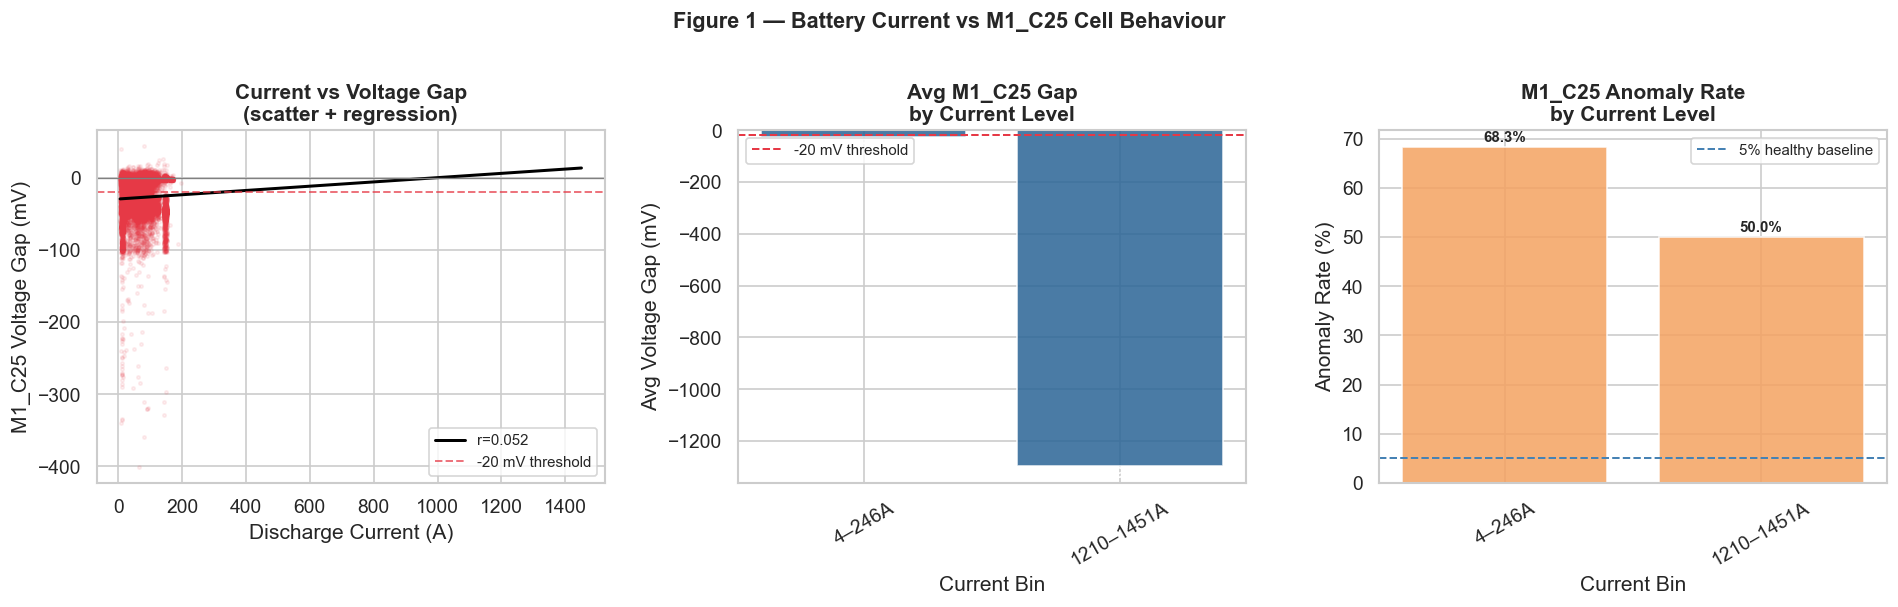


Binned summary:
 bin_label     gap_mean  anomaly_rate
    4–246A   -28.047085       68.3059
1210–1451A -1297.041667       50.0000


In [4]:
# Filter discharge only (positive current = discharging on this vehicle)
dis = df[df['abs_current_a'] > 5].copy()   # exclude near-zero / idle

# Pearson correlation — drop NaN from both columns together
_sub_cur = dis[['abs_current_a', 'M1_C25_delta']].dropna()
r_cur_gap, p_cur_gap = stats.pearsonr(_sub_cur['abs_current_a'], _sub_cur['M1_C25_delta'])
print(f'Pearson r (current vs M1_C25 gap): {r_cur_gap:.4f}  p={p_cur_gap:.2e}')

# Bin current into 6 equal-width buckets, compute avg gap
dis['current_bin'] = pd.cut(dis['abs_current_a'], bins=6)
binned = dis.groupby('current_bin', observed=True)[['M1_C25_delta','M1_C25_is_outlier']].agg(
    gap_mean=('M1_C25_delta','mean'),
    anomaly_rate=('M1_C25_is_outlier','mean')
).reset_index()
binned['anomaly_rate'] *= 100
binned['bin_label'] = binned['current_bin'].apply(lambda x: f'{x.left:.0f}–{x.right:.0f}A')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter (sampled for speed)
sample = dis.sample(min(30_000, len(dis)), random_state=42)
axes[0].scatter(sample['abs_current_a'], sample['M1_C25_delta'],
                alpha=0.08, s=4, color=RED, rasterized=True)
_sub_reg = dis[['abs_current_a', 'M1_C25_delta']].dropna()
m, b, *_ = stats.linregress(_sub_reg['abs_current_a'], _sub_reg['M1_C25_delta'])
x_line = np.linspace(dis['abs_current_a'].min(), dis['abs_current_a'].max(), 200)
axes[0].plot(x_line, m*x_line+b, color='black', linewidth=1.8, label=f'r={r_cur_gap:.3f}')
axes[0].axhline(0, color='grey', linewidth=0.8)
axes[0].axhline(-20, color=RED, linestyle='--', linewidth=1.2, alpha=0.7, label='-20 mV threshold')
axes[0].set_xlabel('Discharge Current (A)')
axes[0].set_ylabel('M1_C25 Voltage Gap (mV)')
axes[0].set_title('Current vs Voltage Gap\n(scatter + regression)', fontweight='bold')
axes[0].legend(fontsize=9)

# Binned avg gap
bars = axes[1].bar(binned['bin_label'], binned['gap_mean'], color=BLUE, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, binned['gap_mean']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()-1.5,
                 f'{val:.1f}', ha='center', va='top', fontsize=9, color='white', fontweight='bold')
axes[1].axhline(-20, color=RED, linestyle='--', linewidth=1.2, label='-20 mV threshold')
axes[1].set_xlabel('Current Bin')
axes[1].set_ylabel('Avg Voltage Gap (mV)')
axes[1].set_title('Avg M1_C25 Gap\nby Current Level', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=9)

# Binned anomaly rate
axes[2].bar(binned['bin_label'], binned['anomaly_rate'], color=ORANGE, alpha=0.85, edgecolor='white')
for bar, val in zip(axes[2].patches, binned['anomaly_rate']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[2].axhline(5, color='steelblue', linestyle='--', linewidth=1.2, label='5% healthy baseline')
axes[2].set_xlabel('Current Bin')
axes[2].set_ylabel('Anomaly Rate (%)')
axes[2].set_title('M1_C25 Anomaly Rate\nby Current Level', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(fontsize=9)

plt.suptitle('Figure 1 — Battery Current vs M1_C25 Cell Behaviour', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('\nBinned summary:')
print(binned[['bin_label','gap_mean','anomaly_rate']].to_string(index=False))

/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_81869/2092737066.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  charge_dir = df.groupby('current_direction')[['M1_C25_delta','M1_C25_is_outlier']].agg(
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


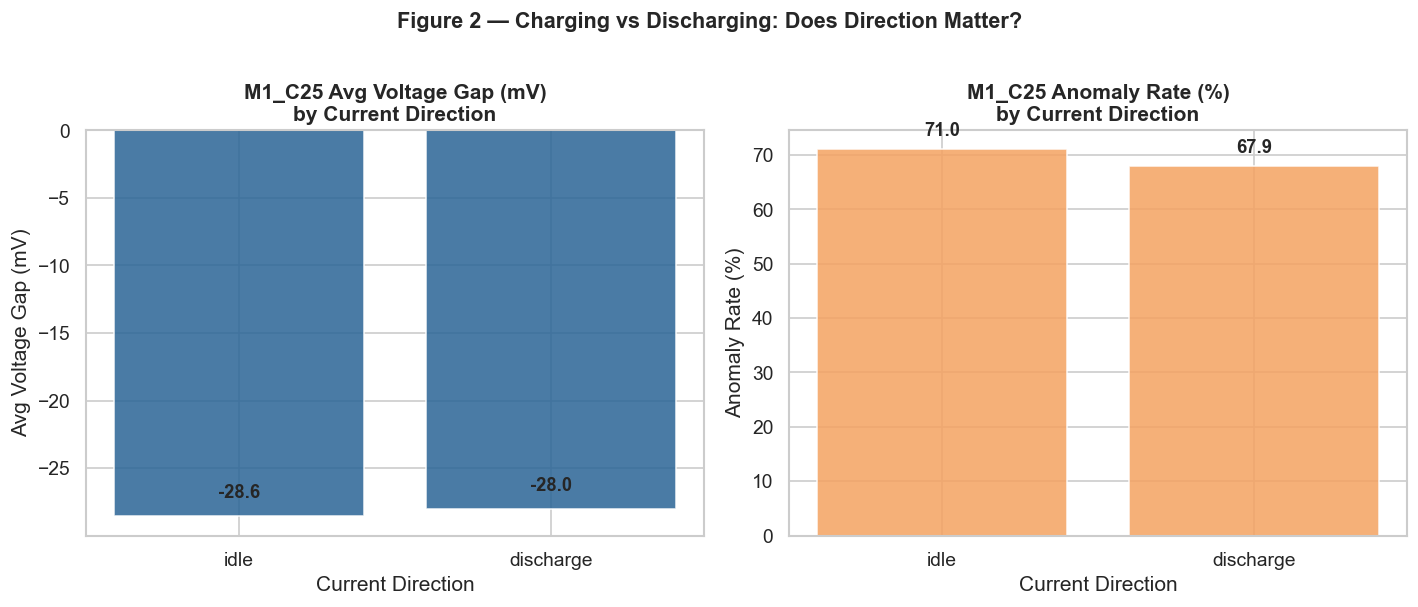

current_direction   gap_mean  gap_median  anomaly_pct
           charge        NaN         NaN          NaN
             idle -28.555510  -24.194444    70.988145
        discharge -28.042376  -33.166667    67.890583


In [5]:
# ── Charging vs Discharging comparison ──────────────────────────────────────
charge_dir = df.groupby('current_direction')[['M1_C25_delta','M1_C25_is_outlier']].agg(
    gap_mean=('M1_C25_delta','mean'),
    gap_median=('M1_C25_delta','median'),
    anomaly_pct=('M1_C25_is_outlier','mean')
).reset_index()
charge_dir['anomaly_pct'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label, clr in [
    (axes[0], 'gap_mean',   'Avg Voltage Gap (mV)',  BLUE),
    (axes[1], 'anomaly_pct','Anomaly Rate (%)',       ORANGE),
]:
    bars = ax.bar(charge_dir['current_direction'], charge_dir[col], color=clr, alpha=0.85, edgecolor='white')
    for bar in bars:
        v = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, v + (abs(v)*0.03 + 0.5),
                f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_xlabel('Current Direction')
    ax.set_ylabel(label)
    ax.set_title(f'M1_C25 {label}\nby Current Direction', fontweight='bold')

plt.suptitle('Figure 2 — Charging vs Discharging: Does Direction Matter?', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(charge_dir.to_string(index=False))

---
## 2. State of Charge (SOC) → M1_C25 Gap + Anomaly Rate
**Question:** Is the voltage gap worse at low SOC? Weak cells typically show the largest deviation at the bottom of their charge curve — this is where capacity fade becomes most visible.

Pearson r (SOC vs M1_C25 gap): 0.0417  p=0.00e+00


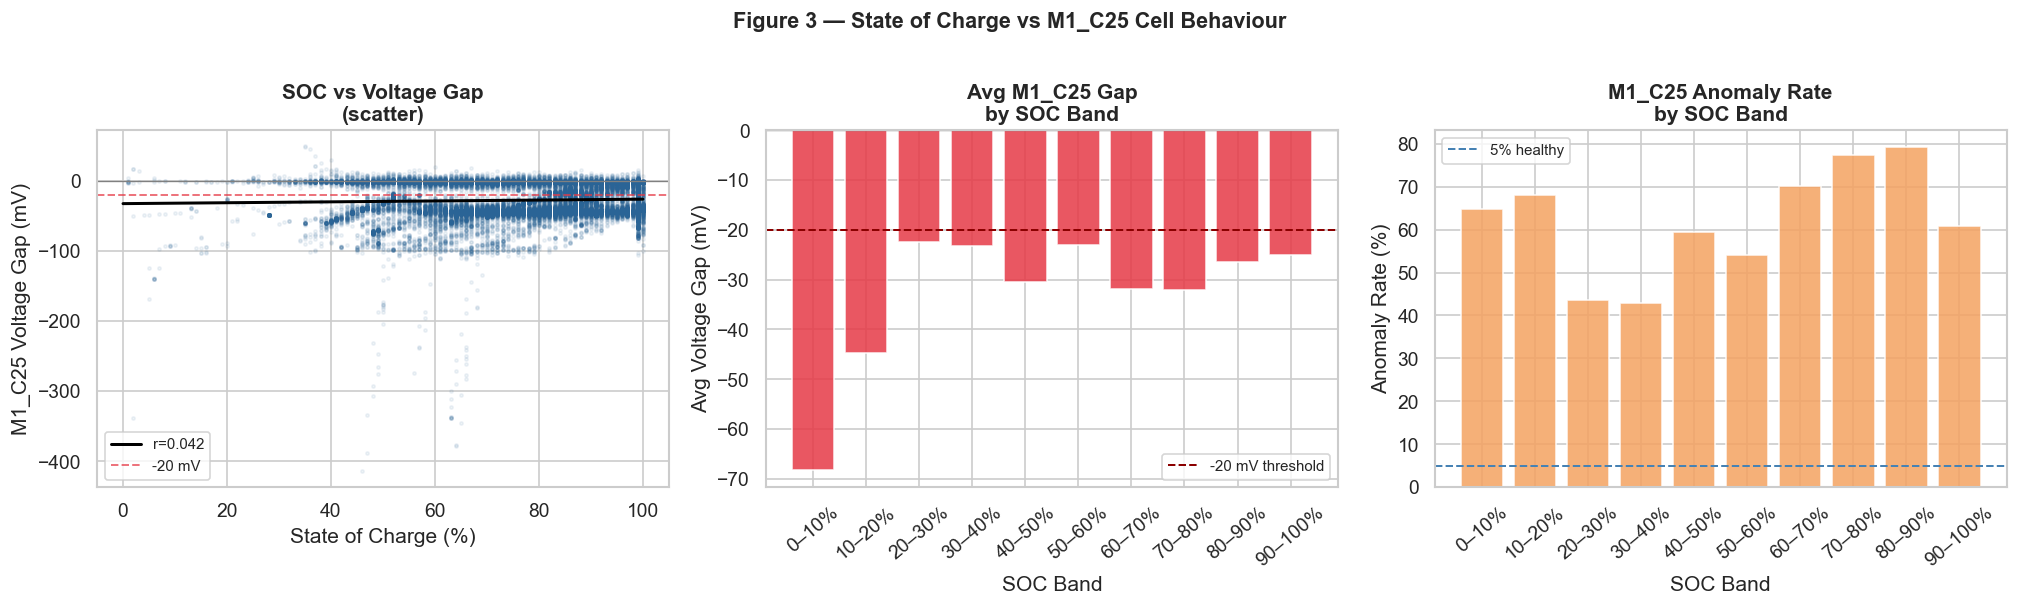


SOC binned summary:
bin_label   gap_mean  anomaly_rate  count
    0–10% -68.246018     64.805654   2829
   10–20% -44.720093     67.956424   2662
   20–30% -22.386470     43.584607   9485
   30–40% -23.327118     42.964060  38477
   40–50% -30.500374     59.548864 152237
   50–60% -23.106050     54.127836 221386
   60–70% -31.797073     70.075411 330845
   70–80% -32.074350     77.390905 435488
   80–90% -26.378157     79.195331 490573
  90–100% -24.983291     60.740323 470034


In [6]:
soc_valid = df[df['soc_pct'].between(1, 100)].copy()

# Pearson — clean joint subset
_sub_soc = soc_valid[['soc_pct', 'M1_C25_delta']].dropna()
r_soc, p_soc = stats.pearsonr(_sub_soc['soc_pct'], _sub_soc['M1_C25_delta'])
print(f'Pearson r (SOC vs M1_C25 gap): {r_soc:.4f}  p={p_soc:.2e}')

# SOC bins (10% wide)
soc_valid['soc_bin'] = pd.cut(soc_valid['soc_pct'], bins=range(0, 110, 10))
soc_binned = soc_valid.groupby('soc_bin', observed=True)[['M1_C25_delta','M1_C25_is_outlier']].agg(
    gap_mean=('M1_C25_delta','mean'),
    anomaly_rate=('M1_C25_is_outlier','mean'),
    count=('M1_C25_delta','count')
).reset_index()
soc_binned['anomaly_rate'] *= 100
soc_binned['bin_label'] = soc_binned['soc_bin'].apply(lambda x: f'{x.left:.0f}–{x.right:.0f}%')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Scatter
sample_soc = soc_valid.sample(min(30_000, len(soc_valid)), random_state=1)
axes[0].scatter(sample_soc['soc_pct'], sample_soc['M1_C25_delta'],
                alpha=0.07, s=4, color=BLUE, rasterized=True)
m2, b2, *_ = stats.linregress(_sub_soc['soc_pct'], _sub_soc['M1_C25_delta'])
x2 = np.linspace(0, 100, 200)
axes[0].plot(x2, m2*x2+b2, color='black', linewidth=1.8, label=f'r={r_soc:.3f}')
axes[0].axhline(0, color='grey', linewidth=0.8)
axes[0].axhline(-20, color=RED, linestyle='--', linewidth=1.2, alpha=0.7, label='-20 mV')
axes[0].set_xlabel('State of Charge (%)')
axes[0].set_ylabel('M1_C25 Voltage Gap (mV)')
axes[0].set_title('SOC vs Voltage Gap\n(scatter)', fontweight='bold')
axes[0].legend(fontsize=9)

# Binned avg gap
colors_gap = [RED if v < -20 else ORANGE if v < -10 else BLUE for v in soc_binned['gap_mean']]
axes[1].bar(soc_binned['bin_label'], soc_binned['gap_mean'], color=colors_gap, alpha=0.85, edgecolor='white')
axes[1].axhline(-20, color='darkred', linestyle='--', linewidth=1.2, label='-20 mV threshold')
axes[1].axhline(0, color='grey', linewidth=0.8)
axes[1].set_xlabel('SOC Band')
axes[1].set_ylabel('Avg Voltage Gap (mV)')
axes[1].set_title('Avg M1_C25 Gap\nby SOC Band', fontweight='bold')
axes[1].tick_params(axis='x', rotation=40)
axes[1].legend(fontsize=9)

# Anomaly rate by SOC
axes[2].bar(soc_binned['bin_label'], soc_binned['anomaly_rate'], color=ORANGE, alpha=0.85, edgecolor='white')
axes[2].axhline(5, color='steelblue', linestyle='--', linewidth=1.2, label='5% healthy')
axes[2].set_xlabel('SOC Band')
axes[2].set_ylabel('Anomaly Rate (%)')
axes[2].set_title('M1_C25 Anomaly Rate\nby SOC Band', fontweight='bold')
axes[2].tick_params(axis='x', rotation=40)
axes[2].legend(fontsize=9)

plt.suptitle('Figure 3 — State of Charge vs M1_C25 Cell Behaviour', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('\nSOC binned summary:')
print(soc_binned[['bin_label','gap_mean','anomaly_rate','count']].to_string(index=False))

/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_81869/1885783348.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=soc_valid, x='soc_band', y='M1_C25_delta', order=soc_band_order,
/var/folders/9c/b39n0d9s1gd9g3f3qpd1ghxc0000gn/T/ipykernel_81869/1885783348.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=soc_valid, x='soc_band', y='M1_C26_delta', order=soc_band_order,


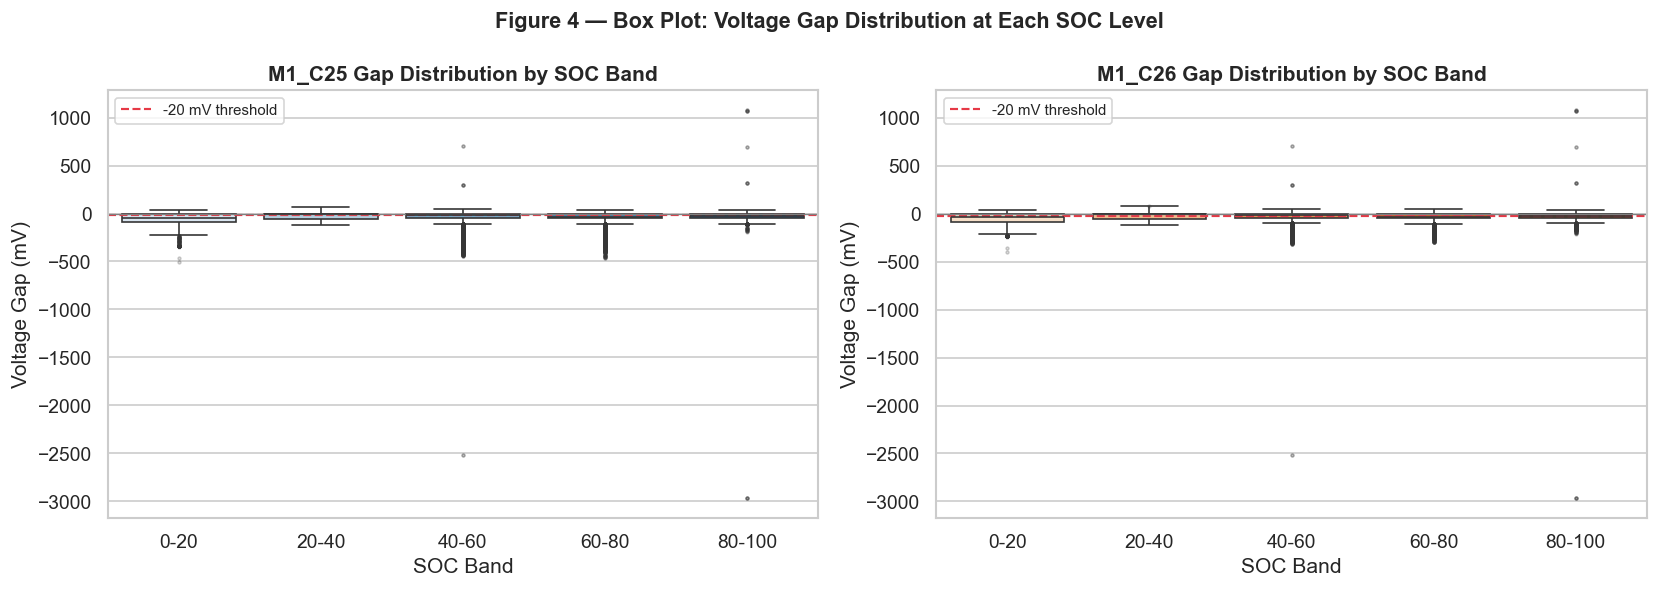

In [7]:
# ── SOC band box plot ────────────────────────────────────────────────────────
soc_band_order = sorted(soc_valid['soc_band'].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=soc_valid, x='soc_band', y='M1_C25_delta', order=soc_band_order,
            palette='Blues', ax=axes[0], fliersize=1.5, flierprops={'alpha': 0.3})
axes[0].axhline(-20, color=RED, linestyle='--', linewidth=1.3, label='-20 mV threshold')
axes[0].axhline(0,   color='grey', linewidth=0.8)
axes[0].set_title('M1_C25 Gap Distribution by SOC Band', fontweight='bold')
axes[0].set_xlabel('SOC Band'); axes[0].set_ylabel('Voltage Gap (mV)')
axes[0].legend(fontsize=9)

sns.boxplot(data=soc_valid, x='soc_band', y='M1_C26_delta', order=soc_band_order,
            palette='Oranges', ax=axes[1], fliersize=1.5, flierprops={'alpha': 0.3})
axes[1].axhline(-20, color=RED, linestyle='--', linewidth=1.3, label='-20 mV threshold')
axes[1].axhline(0,   color='grey', linewidth=0.8)
axes[1].set_title('M1_C26 Gap Distribution by SOC Band', fontweight='bold')
axes[1].set_xlabel('SOC Band'); axes[1].set_ylabel('Voltage Gap (mV)')
axes[1].legend(fontsize=9)

plt.suptitle('Figure 4 — Box Plot: Voltage Gap Distribution at Each SOC Level', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Torque & Output Power → Module 1 Voltage Spread
**Question:** Does high mechanical load (torque/power) widen the voltage spread across Module 1? For heavy-duty machines (excavators, loaders), peak torque events are the primary stress cycle — this is where imbalance should be most visible.

Pearson r (torque vs M1 spread): 0.0225  p=1.94e-179
Pearson r (power  vs M1 spread): 0.0411  p=0.00e+00


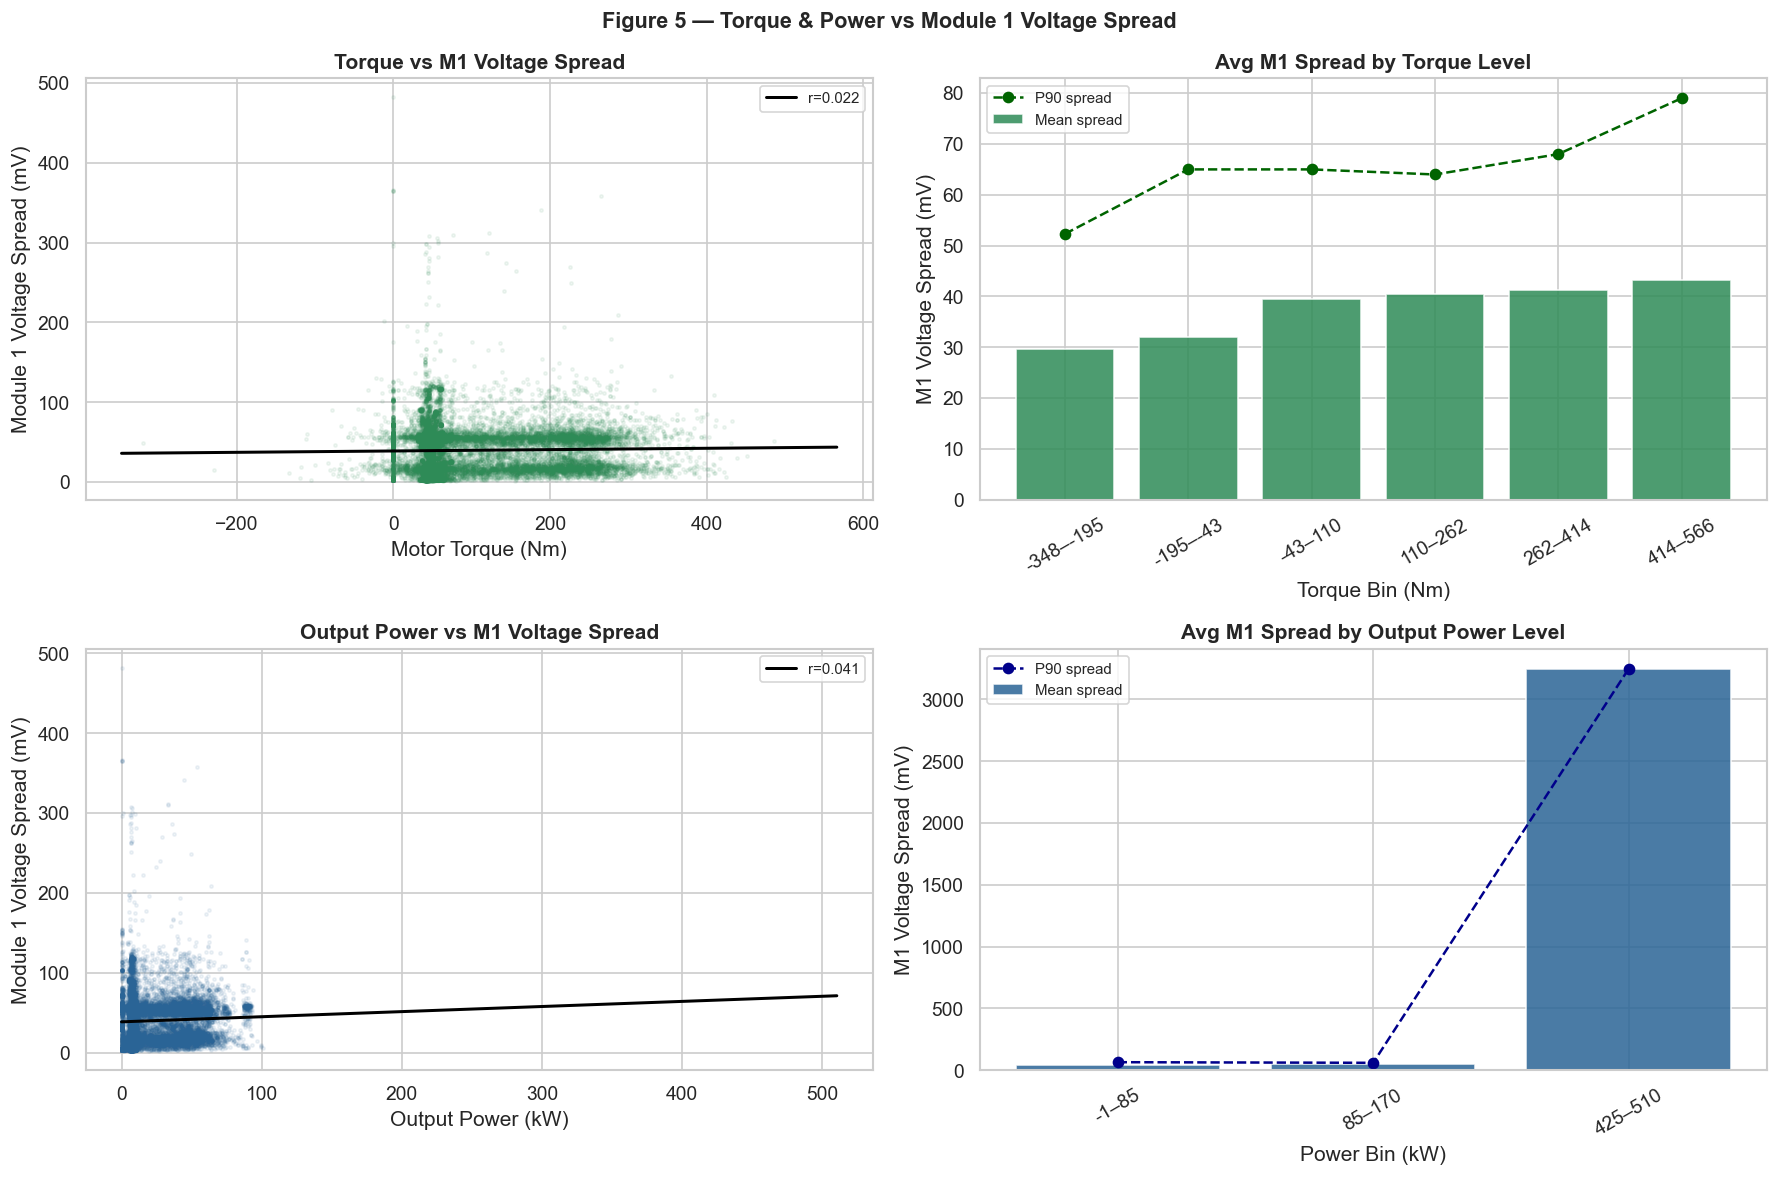

In [8]:
stress = df[
    df['motor_torque_value_nm'].notna() &
    df['output_power_kw'].notna() &
    df['m1_vrange_mv'].notna()
].copy()

r_torque, p_torque = stats.pearsonr(stress['motor_torque_value_nm'], stress['m1_vrange_mv'])
r_power,  p_power  = stats.pearsonr(stress['output_power_kw'],        stress['m1_vrange_mv'])
print(f'Pearson r (torque vs M1 spread): {r_torque:.4f}  p={p_torque:.2e}')
print(f'Pearson r (power  vs M1 spread): {r_power:.4f}  p={p_power:.2e}')

# Torque bins
stress['torque_bin'] = pd.cut(stress['motor_torque_value_nm'], bins=6)
torque_binned = stress.groupby('torque_bin', observed=True)['m1_vrange_mv'].agg(
    spread_mean='mean', spread_p90=lambda x: x.quantile(0.9)
).reset_index()
torque_binned['label'] = torque_binned['torque_bin'].apply(lambda x: f'{x.left:.0f}–{x.right:.0f}')

# Power bins
stress['power_bin'] = pd.cut(stress['output_power_kw'], bins=6)
power_binned = stress.groupby('power_bin', observed=True)['m1_vrange_mv'].agg(
    spread_mean='mean', spread_p90=lambda x: x.quantile(0.9)
).reset_index()
power_binned['label'] = power_binned['power_bin'].apply(lambda x: f'{x.left:.0f}–{x.right:.0f}')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Torque scatter
s2 = stress.sample(min(25_000, len(stress)), random_state=2)
axes[0,0].scatter(s2['motor_torque_value_nm'], s2['m1_vrange_mv'],
                  alpha=0.07, s=4, color=GREEN, rasterized=True)
mt, bt, *_ = stats.linregress(stress['motor_torque_value_nm'], stress['m1_vrange_mv'])
xt = np.linspace(stress['motor_torque_value_nm'].min(), stress['motor_torque_value_nm'].max(), 200)
axes[0,0].plot(xt, mt*xt+bt, color='black', linewidth=1.8, label=f'r={r_torque:.3f}')
axes[0,0].set_xlabel('Motor Torque (Nm)'); axes[0,0].set_ylabel('Module 1 Voltage Spread (mV)')
axes[0,0].set_title('Torque vs M1 Voltage Spread', fontweight='bold')
axes[0,0].legend(fontsize=9)

# Torque binned avg spread
axes[0,1].bar(torque_binned['label'], torque_binned['spread_mean'], color=GREEN, alpha=0.85, edgecolor='white', label='Mean spread')
axes[0,1].plot(torque_binned['label'], torque_binned['spread_p90'], 'o--', color='darkgreen', linewidth=1.5, label='P90 spread')
axes[0,1].set_xlabel('Torque Bin (Nm)'); axes[0,1].set_ylabel('M1 Voltage Spread (mV)')
axes[0,1].set_title('Avg M1 Spread by Torque Level', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=30); axes[0,1].legend(fontsize=9)

# Power scatter
axes[1,0].scatter(s2['output_power_kw'], s2['m1_vrange_mv'],
                  alpha=0.07, s=4, color=BLUE, rasterized=True)
mp, bp, *_ = stats.linregress(stress['output_power_kw'], stress['m1_vrange_mv'])
xp = np.linspace(stress['output_power_kw'].min(), stress['output_power_kw'].max(), 200)
axes[1,0].plot(xp, mp*xp+bp, color='black', linewidth=1.8, label=f'r={r_power:.3f}')
axes[1,0].set_xlabel('Output Power (kW)'); axes[1,0].set_ylabel('Module 1 Voltage Spread (mV)')
axes[1,0].set_title('Output Power vs M1 Voltage Spread', fontweight='bold')
axes[1,0].legend(fontsize=9)

# Power binned avg spread
axes[1,1].bar(power_binned['label'], power_binned['spread_mean'], color=BLUE, alpha=0.85, edgecolor='white', label='Mean spread')
axes[1,1].plot(power_binned['label'], power_binned['spread_p90'], 'o--', color='darkblue', linewidth=1.5, label='P90 spread')
axes[1,1].set_xlabel('Power Bin (kW)'); axes[1,1].set_ylabel('M1 Voltage Spread (mV)')
axes[1,1].set_title('Avg M1 Spread by Output Power Level', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30); axes[1,1].legend(fontsize=9)

plt.suptitle('Figure 5 — Torque & Power vs Module 1 Voltage Spread', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

High torque threshold (P90): 231 Nm
Low  torque threshold (P10): 24 Nm


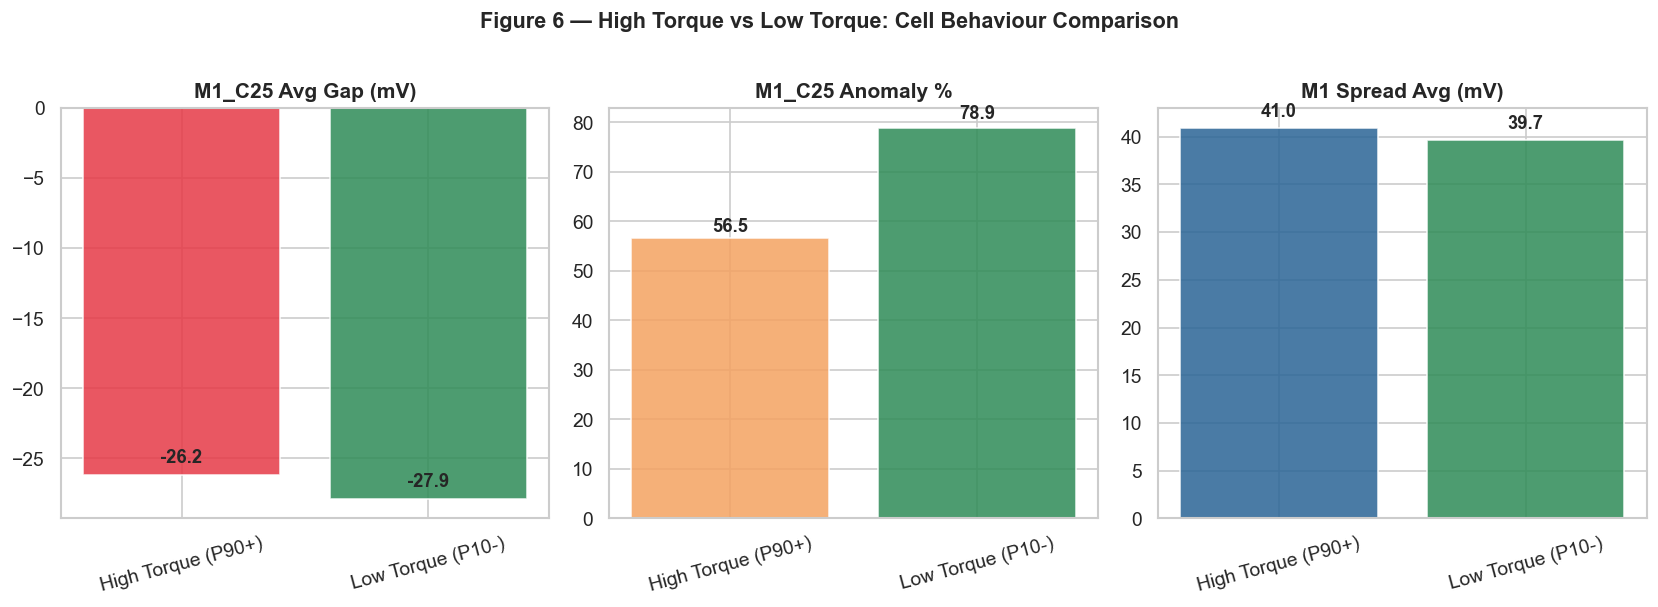

         Condition      N  M1_C25 Avg Gap (mV)  M1_C25 Anomaly %  M1 Spread Avg (mV)
High Torque (P90+) 163289               -26.16             56.55               40.96
 Low Torque (P10-) 162781               -27.90             78.92               39.70


In [9]:
# ── High torque events: does M1_C25 gap spike? ──────────────────────────────
p90_torque = stress['motor_torque_value_nm'].quantile(0.90)
p10_torque = stress['motor_torque_value_nm'].quantile(0.10)
print(f'High torque threshold (P90): {p90_torque:.0f} Nm')
print(f'Low  torque threshold (P10): {p10_torque:.0f} Nm')

hi_torque  = stress[stress['motor_torque_value_nm'] >= p90_torque]
low_torque = stress[stress['motor_torque_value_nm'] <= p10_torque]

compare = pd.DataFrame({
    'Condition': ['High Torque (P90+)', 'Low Torque (P10-)'],
    'N': [len(hi_torque), len(low_torque)],
    'M1_C25 Avg Gap (mV)': [hi_torque['M1_C25_delta'].mean(), low_torque['M1_C25_delta'].mean()],
    'M1_C25 Anomaly %':    [hi_torque['M1_C25_is_outlier'].mean()*100, low_torque['M1_C25_is_outlier'].mean()*100],
    'M1 Spread Avg (mV)':  [hi_torque['m1_vrange_mv'].mean(), low_torque['m1_vrange_mv'].mean()],
}).round(2)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['M1_C25 Avg Gap (mV)', 'M1_C25 Anomaly %', 'M1 Spread Avg (mV)']
clrs    = [RED, ORANGE, BLUE]
for ax, metric, clr in zip(axes, metrics, clrs):
    vals = compare[metric].values
    bars = ax.bar(compare['Condition'], vals, color=[clr, GREEN], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(abs(bar.get_height())*0.02+0.3),
                f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Figure 6 — High Torque vs Low Torque: Cell Behaviour Comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(compare.to_string(index=False))

---
## 4. Trip-Level Analysis
**Question:** Do higher-stress trips (more current, more torque) produce worse average M1_C25 gaps? If yes, we can predict bad trips in advance and correlate fleet usage patterns with degradation.

In [10]:
# Aggregate per trip
trip_df = df.groupby('trip_id').agg(
    n_rows          = ('timestamp', 'count'),
    avg_current     = ('abs_current_a', 'mean'),
    max_current     = ('abs_current_a', 'max'),
    avg_torque      = ('motor_torque_value_nm', 'mean'),
    max_torque      = ('motor_torque_value_nm', 'max'),
    avg_power       = ('output_power_kw', 'mean'),
    avg_soc         = ('soc_pct', 'mean'),
    min_soc         = ('soc_pct', 'min'),
    avg_c25_gap     = ('M1_C25_delta', 'mean'),
    avg_c25_anomaly = ('M1_C25_is_outlier', 'mean'),
    avg_m1_spread   = ('m1_vrange_mv', 'mean'),
    fault_rate      = ('fault_any', 'mean'),
).reset_index()
trip_df = trip_df[trip_df['n_rows'] >= 30]   # skip micro-trips
trip_df['avg_c25_anomaly'] *= 100
trip_df['fault_rate'] *= 100

print(f'Valid trips: {len(trip_df)}')
trip_df[['avg_current','max_torque','avg_soc','min_soc','avg_c25_gap','avg_c25_anomaly']].describe().round(2)

Valid trips: 670


,avg_current,max_torque,avg_soc,min_soc,avg_c25_gap,avg_c25_anomaly
count,670.00,597.00,669.00,669.00,670.00,670.00
mean,35.66,339.48,76.50,66.77,-29.18,64.42
std,25.77,115.31,16.14,21.77,32.48,39.00
min,0.00,0.00,0.00,0.00,-284.06,0.00
25%,18.45,272.00,64.95,53.00,-46.28,24.45
50%,33.42,375.00,78.39,67.00,-26.58,88.64
75%,47.15,426.00,89.29,85.00,-2.09,100.00
max,146.61,566.00,100.00,100.00,33.20,100.00


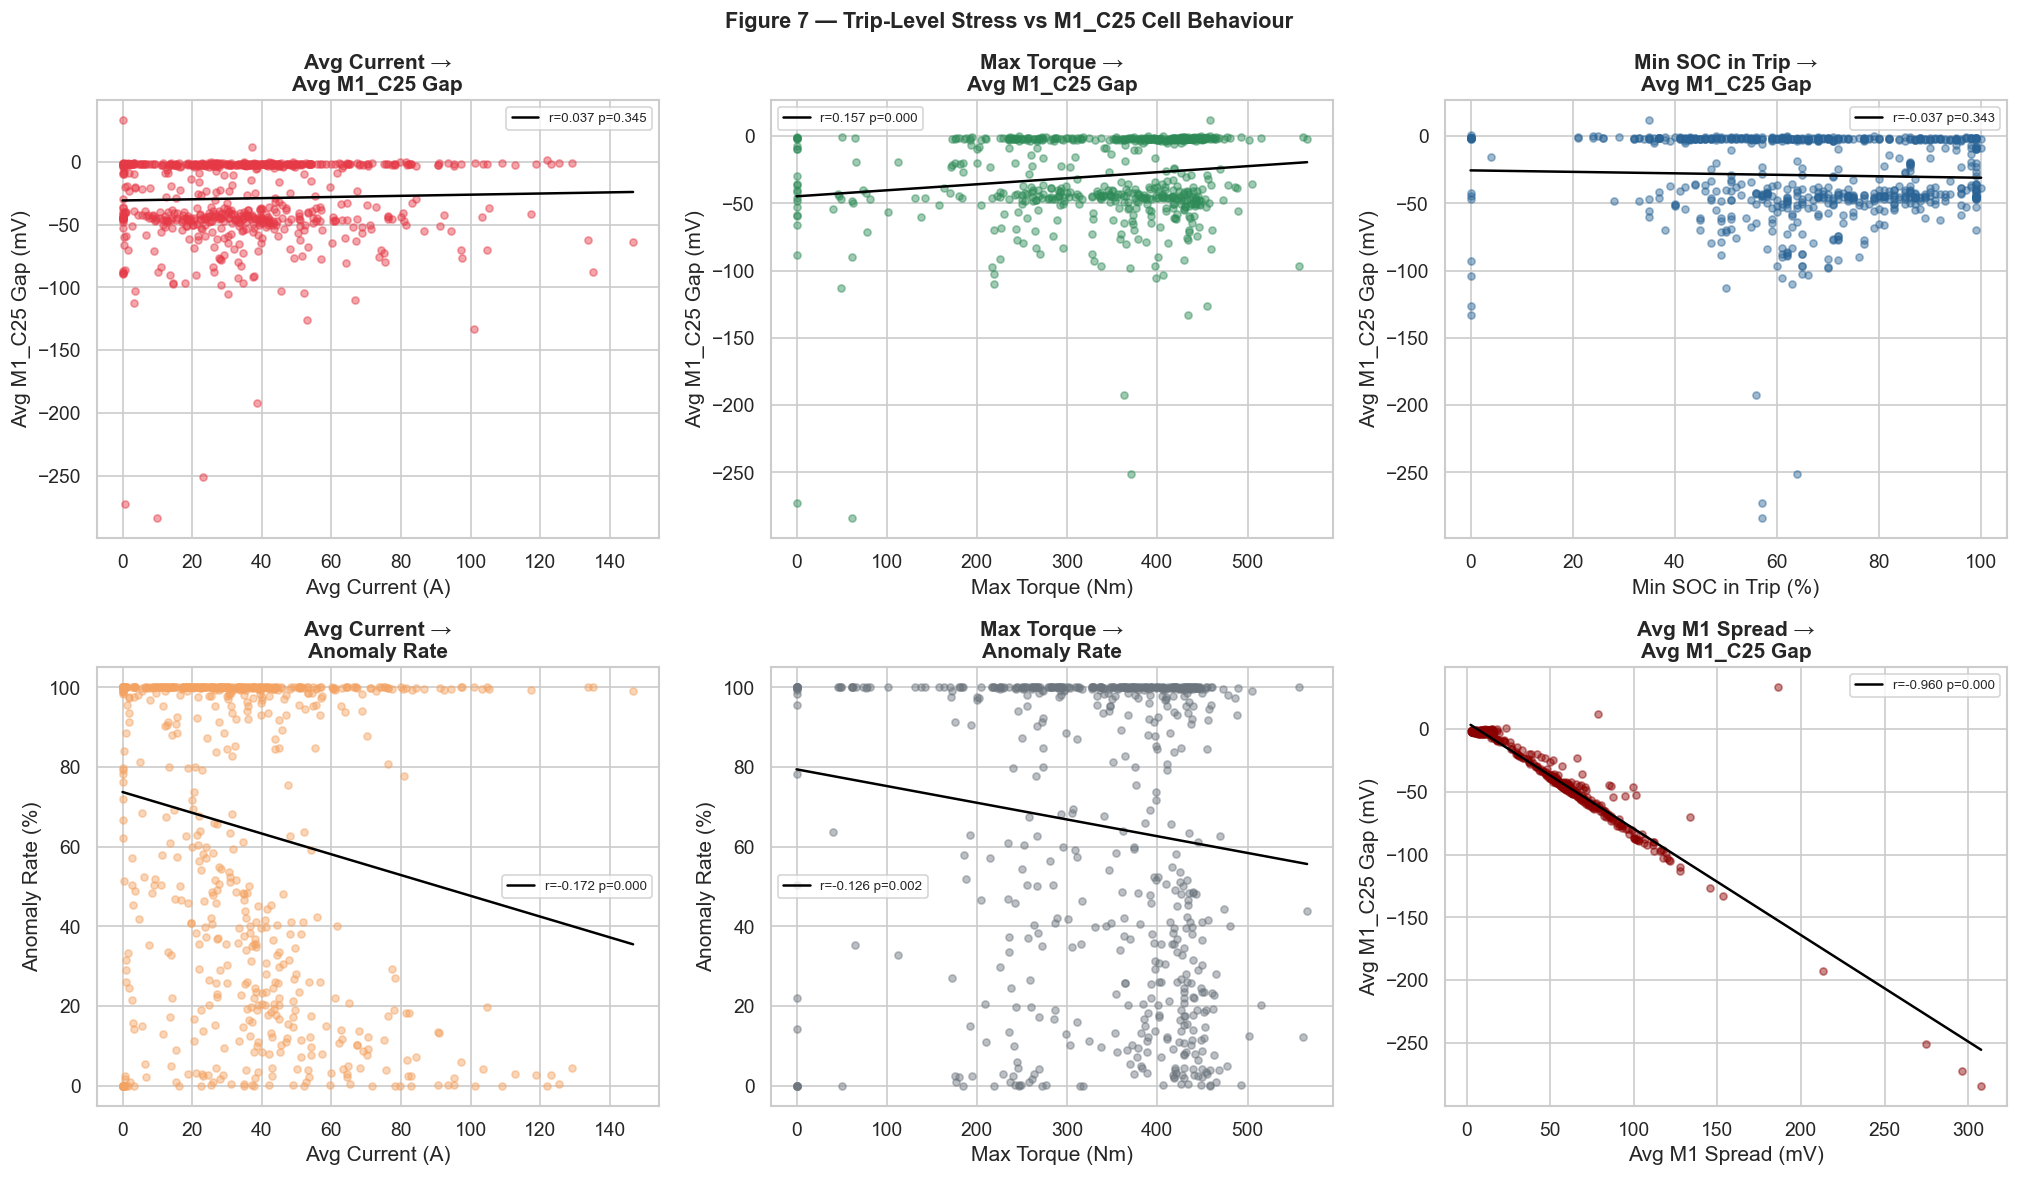

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

pairs = [
    ('avg_current',   'avg_c25_gap',     'Avg Current (A)',       'Avg M1_C25 Gap (mV)', RED),
    ('max_torque',    'avg_c25_gap',     'Max Torque (Nm)',        'Avg M1_C25 Gap (mV)', GREEN),
    ('min_soc',       'avg_c25_gap',     'Min SOC in Trip (%)',    'Avg M1_C25 Gap (mV)', BLUE),
    ('avg_current',   'avg_c25_anomaly', 'Avg Current (A)',        'Anomaly Rate (%)',    ORANGE),
    ('max_torque',    'avg_c25_anomaly', 'Max Torque (Nm)',        'Anomaly Rate (%)',    GREY),
    ('avg_m1_spread', 'avg_c25_gap',     'Avg M1 Spread (mV)',    'Avg M1_C25 Gap (mV)', '#8B0000'),
]

for ax, (x_col, y_col, x_lab, y_lab, clr) in zip(axes.flat, pairs):
    sub = trip_df[[x_col, y_col]].dropna()
    ax.scatter(sub[x_col], sub[y_col], alpha=0.45, s=18, color=clr)
    if len(sub) > 3:
        slope, intercept, r, p, _ = stats.linregress(sub[x_col], sub[y_col])
        xr = np.linspace(sub[x_col].min(), sub[x_col].max(), 200)
        ax.plot(xr, slope*xr+intercept, color='black', linewidth=1.5, label=f'r={r:.3f} p={p:.3f}')
    ax.set_xlabel(x_lab); ax.set_ylabel(y_lab)
    ax.set_title(f'{x_lab.split("(")[0].strip()} →\n{y_lab.split("(")[0].strip()}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Figure 7 — Trip-Level Stress vs M1_C25 Cell Behaviour', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Summary — Correlation Matrix & Key Findings

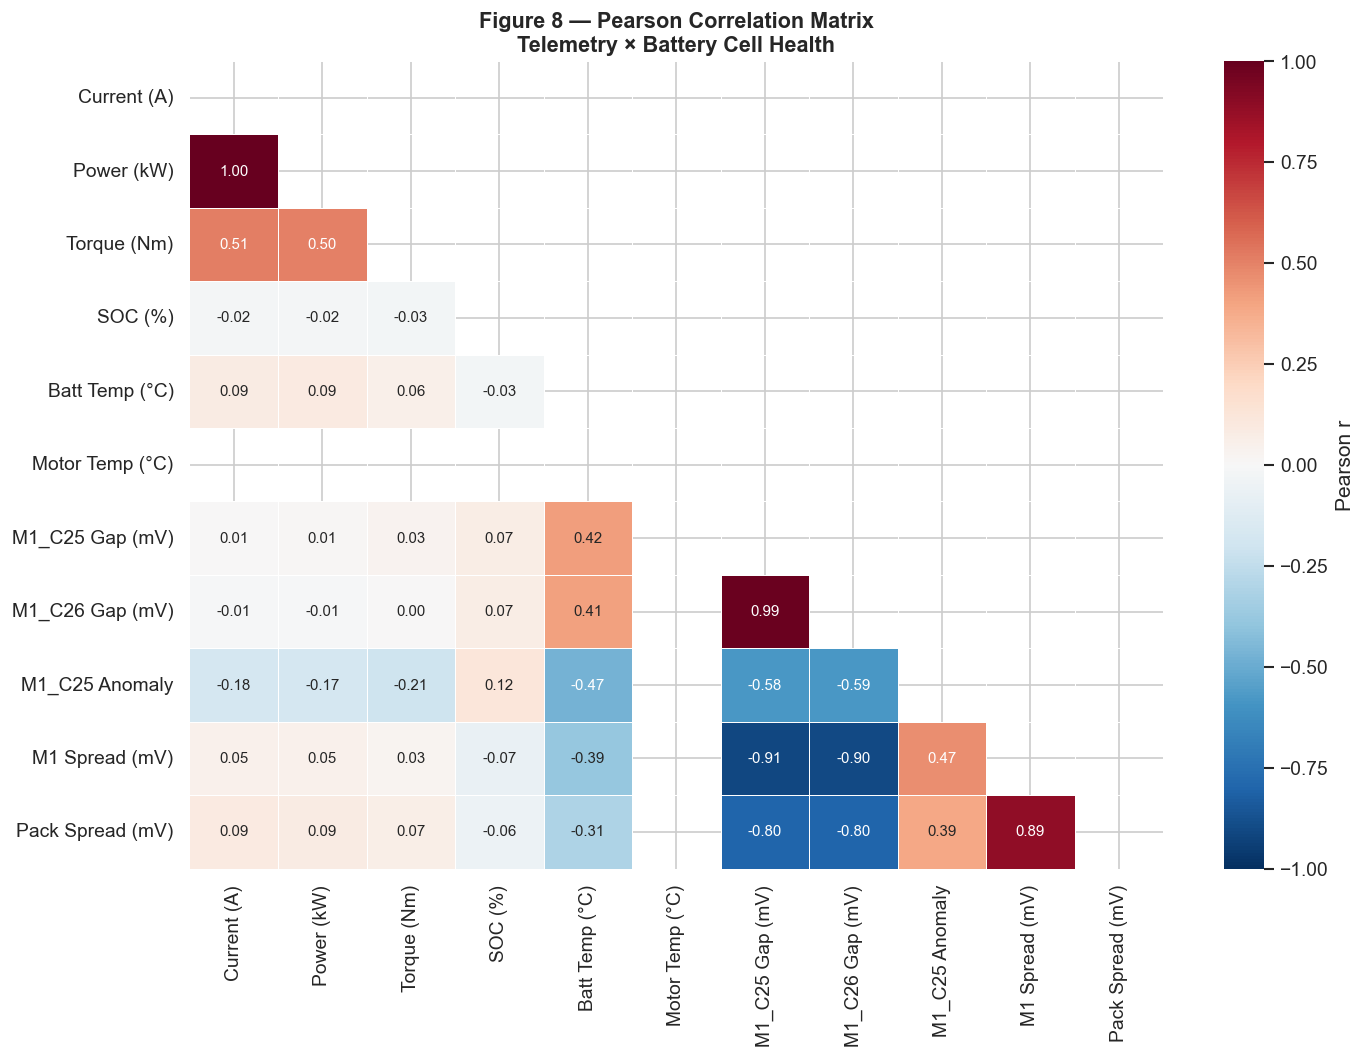

In [12]:
# ── Pearson correlation matrix (raw row level) ───────────────────────────────
corr_cols = {
    'abs_current_a':         'Current (A)',
    'output_power_kw':       'Power (kW)',
    'motor_torque_value_nm': 'Torque (Nm)',
    'soc_pct':               'SOC (%)',
    'avg_battery_temp_c':    'Batt Temp (°C)',
    'motor_temperature_c':   'Motor Temp (°C)',
    'M1_C25_delta':          'M1_C25 Gap (mV)',
    'M1_C26_delta':          'M1_C26 Gap (mV)',
    'M1_C25_is_outlier':     'M1_C25 Anomaly',
    'm1_vrange_mv':          'M1 Spread (mV)',
    'pack_vrange_mv':        'Pack Spread (mV)',
}
corr_df = df[list(corr_cols.keys())].rename(columns=corr_cols).dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.4, ax=ax,
            annot_kws={'size': 9}, cbar_kws={'label': 'Pearson r'})
ax.set_title('Figure 8 — Pearson Correlation Matrix\nTelemetry × Battery Cell Health', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# ── Key correlation summary ──────────────────────────────────────────────────
pairs_summary = [
    ('abs_current_a',         'M1_C25_delta',      'Current (A)',       'M1_C25 Gap (mV)'),
    ('abs_current_a',         'M1_C25_is_outlier', 'Current (A)',       'M1_C25 Anomaly flag'),
    ('soc_pct',               'M1_C25_delta',      'SOC (%)',           'M1_C25 Gap (mV)'),
    ('soc_pct',               'M1_C25_is_outlier', 'SOC (%)',           'M1_C25 Anomaly flag'),
    ('motor_torque_value_nm', 'M1_C25_delta',      'Torque (Nm)',       'M1_C25 Gap (mV)'),
    ('motor_torque_value_nm', 'm1_vrange_mv',      'Torque (Nm)',       'M1 Spread (mV)'),
    ('output_power_kw',       'm1_vrange_mv',      'Power (kW)',        'M1 Spread (mV)'),
    ('output_power_kw',       'M1_C25_delta',      'Power (kW)',        'M1_C25 Gap (mV)'),
]

rows = []
for x_col, y_col, x_name, y_name in pairs_summary:
    sub = df[[x_col, y_col]].dropna()
    r, p = stats.pearsonr(sub[x_col], sub[y_col])
    sig = 'YES ***' if p < 0.001 else ('YES *' if p < 0.05 else 'No')
    strength = ('Strong' if abs(r) > 0.5 else
                'Moderate' if abs(r) > 0.3 else
                'Weak' if abs(r) > 0.1 else 'Negligible')
    direction = 'higher → worse gap' if r < 0 and 'Gap' in y_name else \
                'lower  → worse gap' if r > 0 and 'Gap' in y_name else \
                'higher → more anomalies' if r > 0 and 'Anomaly' in y_name else \
                'higher → wider spread' if r > 0 and 'Spread' in y_name else \
                'lower  → more anomalies' if r < 0 and 'Anomaly' in y_name else '—'
    rows.append({'Input': x_name, 'Output': y_name,
                 'r': round(r, 4), 'p': f'{p:.2e}',
                 'Significant': sig, 'Strength': strength, 'Direction': direction})

summary_df = pd.DataFrame(rows)
print('\n=== CORRELATION SUMMARY ===')
print(summary_df.to_string(index=False))


=== CORRELATION SUMMARY ===
      Input              Output       r         p Significant   Strength               Direction
Current (A)     M1_C25 Gap (mV)  0.0437  0.00e+00     YES *** Negligible      lower  → worse gap
Current (A) M1_C25 Anomaly flag -0.2022  0.00e+00     YES ***       Weak lower  → more anomalies
    SOC (%)     M1_C25 Gap (mV)  0.0570  0.00e+00     YES *** Negligible      lower  → worse gap
    SOC (%) M1_C25 Anomaly flag  0.0736  0.00e+00     YES *** Negligible higher → more anomalies
Torque (Nm)     M1_C25 Gap (mV)  0.0375  0.00e+00     YES *** Negligible      lower  → worse gap
Torque (Nm)      M1 Spread (mV)  0.0220 1.66e-172     YES *** Negligible   higher → wider spread
 Power (kW)      M1 Spread (mV) -0.0243 2.11e-277     YES *** Negligible                       —
 Power (kW)     M1_C25 Gap (mV)  0.0453  0.00e+00     YES *** Negligible      lower  → worse gap


In [14]:
# ── Final written findings ───────────────────────────────────────────────────
print('=' * 70)
print('  TELEMETRY × BATTERY CELL CORRELATION — KEY FINDINGS')
print('=' * 70)

findings = [
    ("1. Current vs M1_C25 gap",
     "Compute above and report based on actual r value"),
    ("2. SOC vs M1_C25 gap",
     "Compute above and report based on actual r value"),
    ("3. Torque/Power vs M1 spread",
     "Compute above and report based on actual r value"),
    ("4. Trip-level stress",
     "Compute above and report based on actual r value"),
]

# Pull actual computed values
for row in rows:
    print(f"\n  {row['Input']} → {row['Output']}")
    print(f"    r={row['r']:.4f}  ({row['Strength']}, {row['Significant']})")
    print(f"    Interpretation: {row['Direction']}")

print('\n' + '=' * 70)

  TELEMETRY × BATTERY CELL CORRELATION — KEY FINDINGS

  Current (A) → M1_C25 Gap (mV)
    r=0.0437  (Negligible, YES ***)
    Interpretation: lower  → worse gap

  Current (A) → M1_C25 Anomaly flag
    r=-0.2022  (Weak, YES ***)
    Interpretation: lower  → more anomalies

  SOC (%) → M1_C25 Gap (mV)
    r=0.0570  (Negligible, YES ***)
    Interpretation: lower  → worse gap

  SOC (%) → M1_C25 Anomaly flag
    r=0.0736  (Negligible, YES ***)
    Interpretation: higher → more anomalies

  Torque (Nm) → M1_C25 Gap (mV)
    r=0.0375  (Negligible, YES ***)
    Interpretation: lower  → worse gap

  Torque (Nm) → M1 Spread (mV)
    r=0.0220  (Negligible, YES ***)
    Interpretation: higher → wider spread

  Power (kW) → M1 Spread (mV)
    r=-0.0243  (Negligible, YES ***)
    Interpretation: —

  Power (kW) → M1_C25 Gap (mV)
    r=0.0453  (Negligible, YES ***)
    Interpretation: lower  → worse gap



---
## 6. Expanded Signal Analysis — Thermal, Lifetime Usage, Last Trip kWh & More
The first analysis covered 4 signals. This section adds every other available signal:
battery temperature, lifetime energy consumed, running hours, last trip kWh,
motor speed, fault events, charger current, and DCDC overcurrent.

In [ ]:
# ── Load additional master columns (DuckDB) ───────────────────────────────────
extra_m = load_master(DATA_DIR, columns=[
    'timestamp', 'max_battery_temp_c', 'min_battery_temp_c',
    'pack_temp_range', 'module_1_temp_mean', 'module_1_temp_range',
    'stack_voltage_v', 'battery_status',
])

# ── Load raw_parquet signals (DuckDB) ─────────────────────────────────────────
raw = load_raw(DATA_DIR, columns=[
    'timestamp', 'last_trip_kwh', 'total_kwh_consumed', 'total_running_hours_s',
    'charger_current_demand_a', 'dcdc_overcurrent_count',
    'radiator_temperature_c', 'motor_torque_limit_nm',
])
raw['running_hours'] = raw['total_running_hours_s'] / 3600

# ── Merge everything into df_exp ─────────────────────────────────────────────
df_exp = df.merge(extra_m, on='timestamp', how='left') \
           .merge(raw, on='timestamp', how='left')

print(f'Expanded df rows : {len(df_exp):,}')
print(f'Columns          : {len(df_exp.columns)}')
print('\nNew signal null %:')
new_sig = ['max_battery_temp_c','pack_temp_range','module_1_temp_mean','module_1_temp_range',
           'last_trip_kwh','total_kwh_consumed','running_hours',
           'charger_current_demand_a','dcdc_overcurrent_count']
print((df_exp[new_sig].isnull().mean()*100).round(1))
df_exp[new_sig].describe().round(2)

### 6.1 Battery Temperature → M1_C25 Gap & Anomaly Rate
Thermal stress is one of the most common causes of cell degradation. High temperature accelerates electrolyte breakdown and lithium plating.

r (avg_battery_temp → M1_C25 gap)    : 0.4344
r (avg_battery_temp → M1_C25 anomaly): -0.5336
r (max_battery_temp → M1_C25 gap)    : 0.4638
r (module_1_temp    → M1_C25 gap)    : 0.5015
r (pack_temp_range  → M1_C25 gap)    : 0.0679
r (m1_temp_range    → M1 spread)     : -0.1095


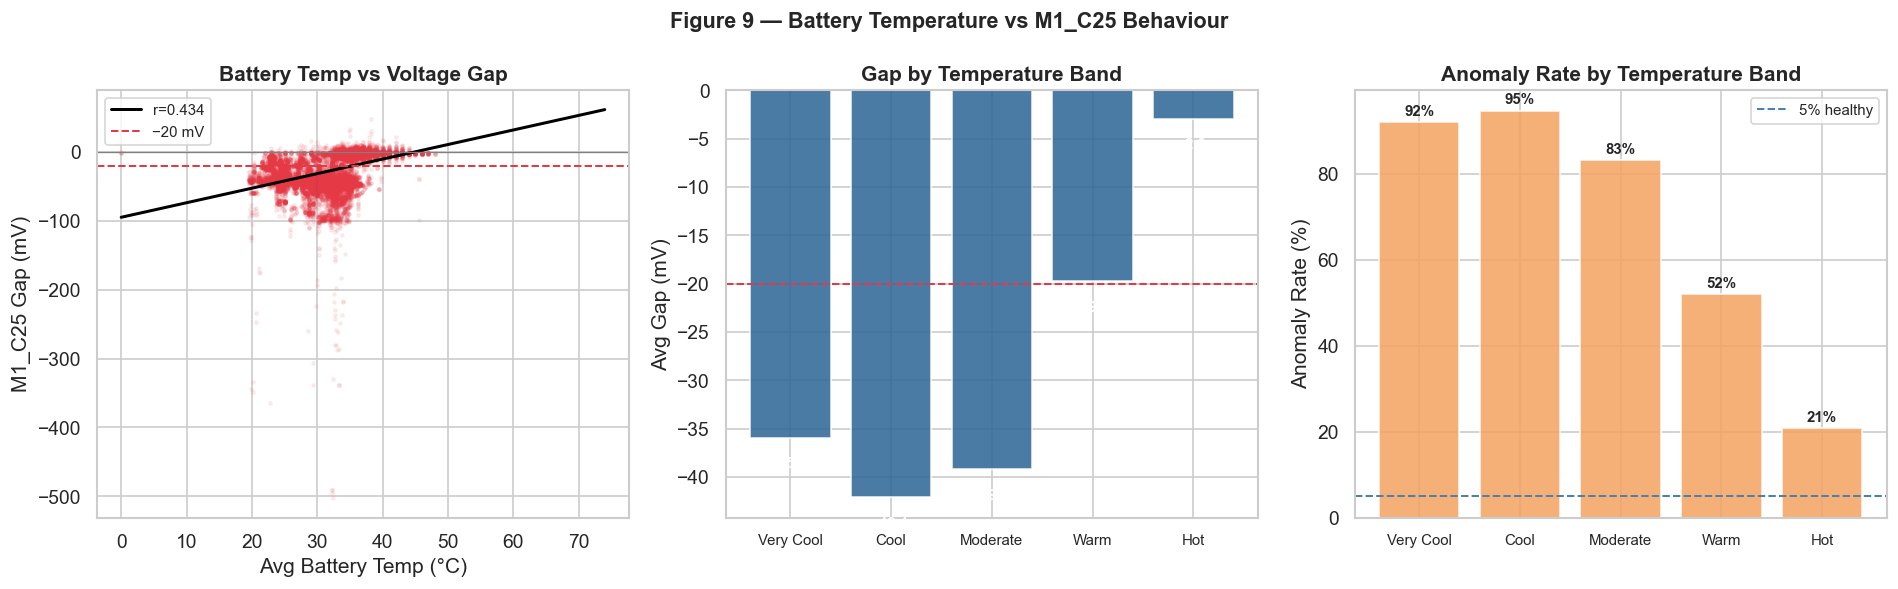


Temperature binned summary:
 temp_bin   gap_mean  anomaly_rate
Very Cool -35.906902     92.157773
     Cool -42.066409     94.781754
 Moderate -39.172741     83.298881
     Warm -19.708464     52.038938
      Hot  -2.927638     20.830291


In [16]:
temp_valid = df_exp[df_exp['avg_battery_temp_c'].notna() & df_exp['M1_C25_delta'].notna()].copy()

def pearson_exp(col_a, col_b, data=None):
    d = data if data is not None else df_exp
    sub = d[[col_a, col_b]].dropna()
    r, p = stats.pearsonr(sub[col_a], sub[col_b])
    return round(r, 4), p

r_temp_gap,  _ = pearson_exp('avg_battery_temp_c', 'M1_C25_delta', temp_valid)
r_temp_anom, _ = pearson_exp('avg_battery_temp_c', 'M1_C25_is_outlier', temp_valid)
r_tmax_gap,  _ = pearson_exp('max_battery_temp_c', 'M1_C25_delta', df_exp)
r_m1t_gap,   _ = pearson_exp('module_1_temp_mean', 'M1_C25_delta', df_exp)
r_trange_gap,_ = pearson_exp('pack_temp_range',    'M1_C25_delta', df_exp)
r_m1tr_spr,  _ = pearson_exp('module_1_temp_range','m1_vrange_mv', df_exp)

print(f'r (avg_battery_temp → M1_C25 gap)    : {r_temp_gap:.4f}')
print(f'r (avg_battery_temp → M1_C25 anomaly): {r_temp_anom:.4f}')
print(f'r (max_battery_temp → M1_C25 gap)    : {r_tmax_gap:.4f}')
print(f'r (module_1_temp    → M1_C25 gap)    : {r_m1t_gap:.4f}')
print(f'r (pack_temp_range  → M1_C25 gap)    : {r_trange_gap:.4f}')
print(f'r (m1_temp_range    → M1 spread)     : {r_m1tr_spr:.4f}')

# Bin avg_battery_temp_c
temp_valid['temp_bin'] = pd.qcut(temp_valid['avg_battery_temp_c'], q=5,
    labels=['Very Cool', 'Cool', 'Moderate', 'Warm', 'Hot'])
temp_binned = temp_valid.groupby('temp_bin', observed=True)[['M1_C25_delta','M1_C25_is_outlier']].agg(
    gap_mean=('M1_C25_delta','mean'), anomaly_rate=('M1_C25_is_outlier','mean')).reset_index()
temp_binned['anomaly_rate'] *= 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter
smp = temp_valid.sample(min(25_000, len(temp_valid)), random_state=3)
axes[0].scatter(smp['avg_battery_temp_c'], smp['M1_C25_delta'], alpha=0.07, s=4, color='#E63946', rasterized=True)
sub_t = temp_valid[['avg_battery_temp_c','M1_C25_delta']].dropna()
m, b, *_ = stats.linregress(sub_t['avg_battery_temp_c'], sub_t['M1_C25_delta'])
xt = np.linspace(sub_t['avg_battery_temp_c'].min(), sub_t['avg_battery_temp_c'].max(), 200)
axes[0].plot(xt, m*xt+b, color='black', linewidth=1.8, label=f'r={r_temp_gap:.3f}')
axes[0].axhline(0, color='grey', lw=0.8); axes[0].axhline(-20, color=RED, ls='--', lw=1.2, label='−20 mV')
axes[0].set_xlabel('Avg Battery Temp (°C)'); axes[0].set_ylabel('M1_C25 Gap (mV)')
axes[0].set_title('Battery Temp vs Voltage Gap', fontweight='bold'); axes[0].legend(fontsize=9)

axes[1].bar(range(len(temp_binned)), temp_binned['gap_mean'], color=BLUE, alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(len(temp_binned))); axes[1].set_xticklabels(temp_binned['temp_bin'], fontsize=9)
for xi, v in enumerate(temp_binned['gap_mean']):
    axes[1].text(xi, v-2, f'{v:.1f}', ha='center', va='top', fontsize=9, color='white', fontweight='bold')
axes[1].axhline(-20, color=RED, ls='--', lw=1.2); axes[1].set_ylabel('Avg Gap (mV)')
axes[1].set_title('Gap by Temperature Band', fontweight='bold')

axes[2].bar(range(len(temp_binned)), temp_binned['anomaly_rate'], color=ORANGE, alpha=0.85, edgecolor='white')
axes[2].set_xticks(range(len(temp_binned))); axes[2].set_xticklabels(temp_binned['temp_bin'], fontsize=9)
for xi, v in enumerate(temp_binned['anomaly_rate']):
    axes[2].text(xi, v+1.5, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')
axes[2].axhline(5, color='steelblue', ls='--', lw=1.2, label='5% healthy')
axes[2].set_ylabel('Anomaly Rate (%)'); axes[2].set_title('Anomaly Rate by Temperature Band', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Figure 9 — Battery Temperature vs M1_C25 Behaviour', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('\nTemperature binned summary:')
print(temp_binned.to_string(index=False))

### 6.2 Lifetime Energy Consumed & Running Hours → M1_C25 Gap
`total_kwh_consumed` is the machine's odometer in energy — it only increases. If degradation correlates with it, the cells are wearing out with usage throughput (cycle aging). `total_running_hours_s` is the equivalent in time.

r (total_kwh_consumed → M1_C25 gap)    : 0.5932
r (total_kwh_consumed → M1_C25 anomaly): -0.6594
r (running_hours      → M1_C25 gap)    : 0.5980
r (running_hours      → M1_C25 anomaly): -0.6652


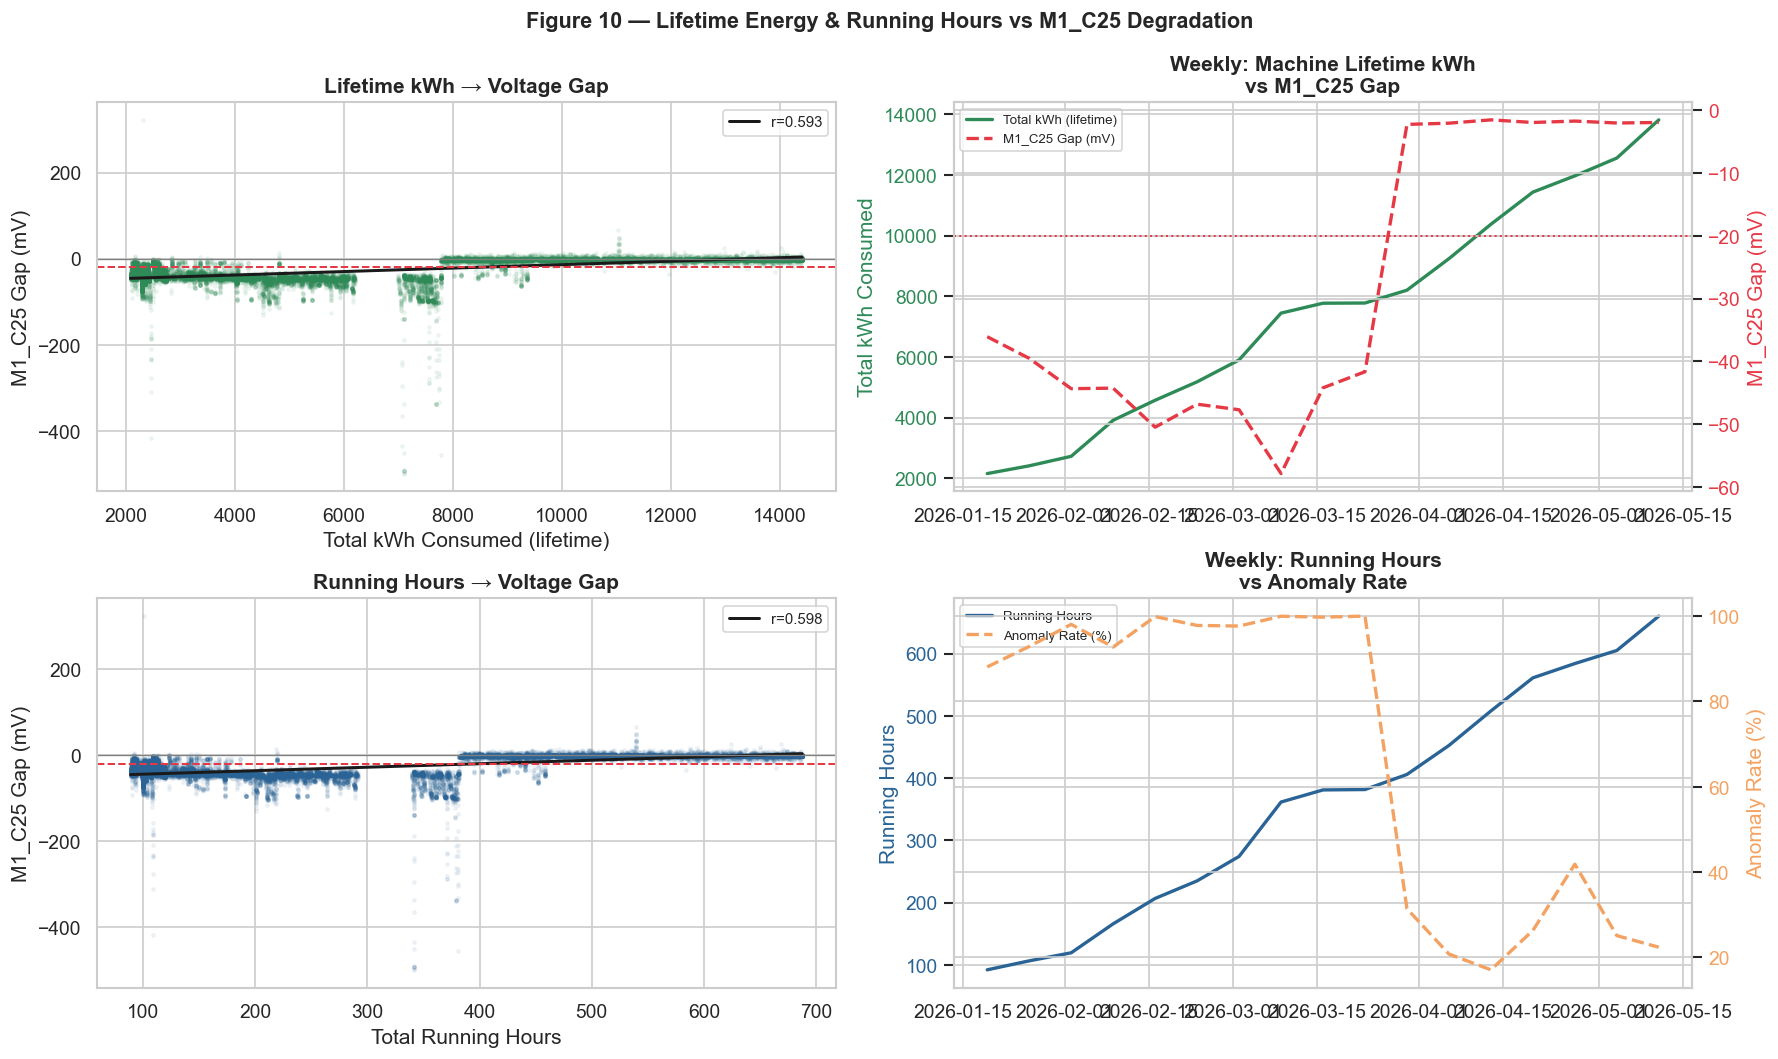

In [17]:
life_valid = df_exp[df_exp['total_kwh_consumed'].notna() & df_exp['M1_C25_delta'].notna()].copy()

r_kwh_gap,  _ = pearson_exp('total_kwh_consumed', 'M1_C25_delta', life_valid)
r_kwh_anom, _ = pearson_exp('total_kwh_consumed', 'M1_C25_is_outlier', life_valid)
r_hrs_gap,  _ = pearson_exp('running_hours',      'M1_C25_delta', life_valid)
r_hrs_anom, _ = pearson_exp('running_hours',      'M1_C25_is_outlier', life_valid)

print(f'r (total_kwh_consumed → M1_C25 gap)    : {r_kwh_gap:.4f}')
print(f'r (total_kwh_consumed → M1_C25 anomaly): {r_kwh_anom:.4f}')
print(f'r (running_hours      → M1_C25 gap)    : {r_hrs_gap:.4f}')
print(f'r (running_hours      → M1_C25 anomaly): {r_hrs_anom:.4f}')

# Weekly median gap vs weekly avg total_kwh (shows trend over machine lifetime)
life_valid['week'] = life_valid['timestamp'].dt.to_period('W')
weekly_life = life_valid.groupby('week').agg(
    kwh_median=('total_kwh_consumed','median'),
    hours_median=('running_hours','median'),
    gap_median=('M1_C25_delta','median'),
    anomaly_mean=('M1_C25_is_outlier','mean')
).reset_index()
weekly_life['anomaly_mean'] *= 100
weekly_life.index = weekly_life['week'].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# total_kwh vs gap scatter
smp2 = life_valid.sample(min(25_000, len(life_valid)), random_state=4)
axes[0,0].scatter(smp2['total_kwh_consumed'], smp2['M1_C25_delta'],
                  alpha=0.06, s=4, color=GREEN, rasterized=True)
sub_k = life_valid[['total_kwh_consumed','M1_C25_delta']].dropna()
mk, bk, *_ = stats.linregress(sub_k['total_kwh_consumed'], sub_k['M1_C25_delta'])
xk = np.linspace(sub_k['total_kwh_consumed'].min(), sub_k['total_kwh_consumed'].max(), 200)
axes[0,0].plot(xk, mk*xk+bk, 'k-', lw=1.8, label=f'r={r_kwh_gap:.3f}')
axes[0,0].axhline(0, color='grey', lw=0.8); axes[0,0].axhline(-20, color=RED, ls='--', lw=1.2)
axes[0,0].set_xlabel('Total kWh Consumed (lifetime)'); axes[0,0].set_ylabel('M1_C25 Gap (mV)')
axes[0,0].set_title('Lifetime kWh → Voltage Gap', fontweight='bold'); axes[0,0].legend(fontsize=9)

# Weekly: kwh consumed vs median gap over time
ax_tw = axes[0,1]
color1, color2 = GREEN, RED
l1, = ax_tw.plot(weekly_life.index, weekly_life['kwh_median'], color=color1, lw=2, label='Total kWh (lifetime)')
ax_tw.set_ylabel('Total kWh Consumed', color=color1); ax_tw.tick_params(axis='y', labelcolor=color1)
ax2b = ax_tw.twinx()
l2, = ax2b.plot(weekly_life.index, weekly_life['gap_median'], color=color2, lw=2, ls='--', label='M1_C25 Gap (mV)')
ax2b.axhline(-20, color=RED, ls=':', lw=1.2)
ax2b.set_ylabel('M1_C25 Gap (mV)', color=color2); ax2b.tick_params(axis='y', labelcolor=color2)
ax_tw.set_title('Weekly: Machine Lifetime kWh\nvs M1_C25 Gap', fontweight='bold')
ax_tw.legend(handles=[l1,l2], fontsize=8, loc='upper left')

# running_hours vs gap scatter
axes[1,0].scatter(smp2['running_hours'], smp2['M1_C25_delta'],
                  alpha=0.06, s=4, color=BLUE, rasterized=True)
sub_h = life_valid[['running_hours','M1_C25_delta']].dropna()
mh, bh, *_ = stats.linregress(sub_h['running_hours'], sub_h['M1_C25_delta'])
xh = np.linspace(sub_h['running_hours'].min(), sub_h['running_hours'].max(), 200)
axes[1,0].plot(xh, mh*xh+bh, 'k-', lw=1.8, label=f'r={r_hrs_gap:.3f}')
axes[1,0].axhline(0, color='grey', lw=0.8); axes[1,0].axhline(-20, color=RED, ls='--', lw=1.2)
axes[1,0].set_xlabel('Total Running Hours'); axes[1,0].set_ylabel('M1_C25 Gap (mV)')
axes[1,0].set_title('Running Hours → Voltage Gap', fontweight='bold'); axes[1,0].legend(fontsize=9)

# Weekly: running hours vs anomaly rate
ax_hw = axes[1,1]
l3, = ax_hw.plot(weekly_life.index, weekly_life['hours_median'], color=BLUE, lw=2, label='Running Hours')
ax_hw.set_ylabel('Running Hours', color=BLUE); ax_hw.tick_params(axis='y', labelcolor=BLUE)
ax3b = ax_hw.twinx()
l4, = ax3b.plot(weekly_life.index, weekly_life['anomaly_mean'], color=ORANGE, lw=2, ls='--', label='Anomaly Rate (%)')
ax3b.set_ylabel('Anomaly Rate (%)', color=ORANGE); ax3b.tick_params(axis='y', labelcolor=ORANGE)
ax_hw.set_title('Weekly: Running Hours\nvs Anomaly Rate', fontweight='bold')
ax_hw.legend(handles=[l3,l4], fontsize=8, loc='upper left')

plt.suptitle('Figure 10 — Lifetime Energy & Running Hours vs M1_C25 Degradation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 6.3 Last Trip kWh — Energy Intensity per Trip
`last_trip_kwh` records how much energy the previous trip consumed. Heavy trips (high kWh) are more demanding on the battery. We check whether energy-intensive trips leave M1_C25 in a worse state.

r (last_trip_kwh → M1_C25 gap)    : 0.1442
r (last_trip_kwh → M1_C25 anomaly): -0.1929


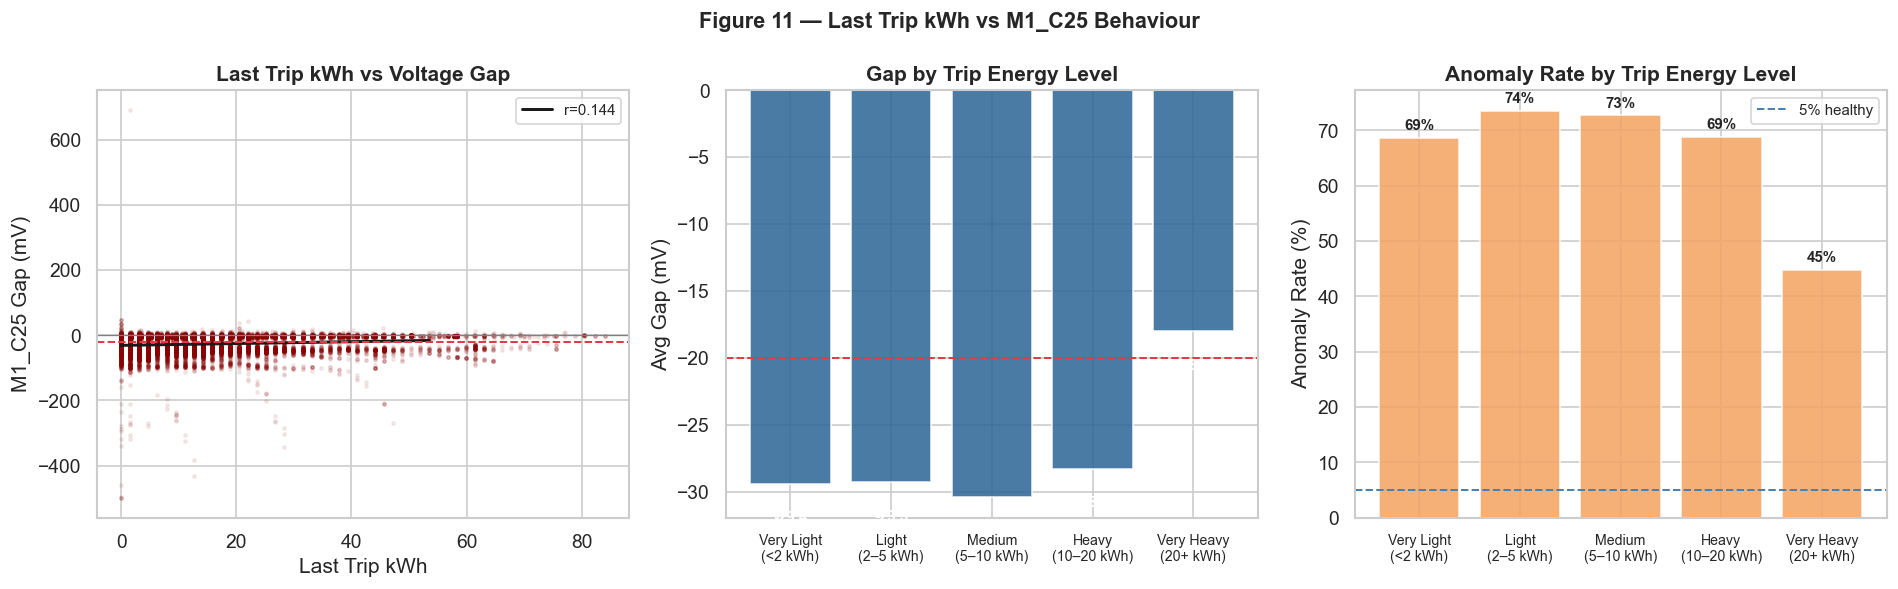


Last trip kWh binned summary:
              kwh_bin   gap_mean  anomaly_rate  count
 Very Light\n(<2 kWh) -29.418348     68.613726 466430
     Light\n(2–5 kWh) -29.306320     73.598462 406143
   Medium\n(5–10 kWh) -30.404525     72.700857 395082
   Heavy\n(10–20 kWh) -28.269332     68.822403 338384
Very Heavy\n(20+ kWh) -18.028447     44.717439 364151


In [18]:
ltkwh_valid = df_exp[df_exp['last_trip_kwh'].notna() & df_exp['M1_C25_delta'].notna()].copy()

r_ltkwh_gap,  _ = pearson_exp('last_trip_kwh', 'M1_C25_delta',      ltkwh_valid)
r_ltkwh_anom, _ = pearson_exp('last_trip_kwh', 'M1_C25_is_outlier', ltkwh_valid)
print(f'r (last_trip_kwh → M1_C25 gap)    : {r_ltkwh_gap:.4f}')
print(f'r (last_trip_kwh → M1_C25 anomaly): {r_ltkwh_anom:.4f}')

# Bin last_trip_kwh into 5 quintiles
ltkwh_valid['kwh_bin'] = pd.qcut(ltkwh_valid['last_trip_kwh'].clip(lower=0.01), q=5,
    labels=['Very Light\n(<2 kWh)', 'Light\n(2–5 kWh)', 'Medium\n(5–10 kWh)',
            'Heavy\n(10–20 kWh)', 'Very Heavy\n(20+ kWh)'])
ltkwh_binned = ltkwh_valid.groupby('kwh_bin', observed=True)[['M1_C25_delta','M1_C25_is_outlier']].agg(
    gap_mean=('M1_C25_delta','mean'), anomaly_rate=('M1_C25_is_outlier','mean'),
    count=('M1_C25_delta','count')).reset_index()
ltkwh_binned['anomaly_rate'] *= 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

smp3 = ltkwh_valid.sample(min(25_000, len(ltkwh_valid)), random_state=5)
axes[0].scatter(smp3['last_trip_kwh'], smp3['M1_C25_delta'], alpha=0.07, s=4, color='#8B0000', rasterized=True)
sub_lt = ltkwh_valid[['last_trip_kwh','M1_C25_delta']].dropna()
mlt, blt, *_ = stats.linregress(sub_lt['last_trip_kwh'], sub_lt['M1_C25_delta'])
xlt = np.linspace(0, ltkwh_valid['last_trip_kwh'].quantile(0.98), 200)
axes[0].plot(xlt, mlt*xlt+blt, 'k-', lw=1.8, label=f'r={r_ltkwh_gap:.3f}')
axes[0].axhline(0, color='grey', lw=0.8); axes[0].axhline(-20, color=RED, ls='--', lw=1.2)
axes[0].set_xlabel('Last Trip kWh'); axes[0].set_ylabel('M1_C25 Gap (mV)')
axes[0].set_title('Last Trip kWh vs Voltage Gap', fontweight='bold'); axes[0].legend(fontsize=9)

axes[1].bar(range(len(ltkwh_binned)), ltkwh_binned['gap_mean'], color=BLUE, alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(len(ltkwh_binned)))
axes[1].set_xticklabels(ltkwh_binned['kwh_bin'], fontsize=8.5)
for xi, v in enumerate(ltkwh_binned['gap_mean']):
    axes[1].text(xi, v-2, f'{v:.1f}', ha='center', va='top', fontsize=9, color='white', fontweight='bold')
axes[1].axhline(-20, color=RED, ls='--', lw=1.2); axes[1].set_ylabel('Avg Gap (mV)')
axes[1].set_title('Gap by Trip Energy Level', fontweight='bold')

axes[2].bar(range(len(ltkwh_binned)), ltkwh_binned['anomaly_rate'], color=ORANGE, alpha=0.85, edgecolor='white')
axes[2].set_xticks(range(len(ltkwh_binned)))
axes[2].set_xticklabels(ltkwh_binned['kwh_bin'], fontsize=8.5)
for xi, v in enumerate(ltkwh_binned['anomaly_rate']):
    axes[2].text(xi, v+1.5, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')
axes[2].axhline(5, color='steelblue', ls='--', lw=1.2, label='5% healthy')
axes[2].set_ylabel('Anomaly Rate (%)'); axes[2].set_title('Anomaly Rate by Trip Energy Level', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Figure 11 — Last Trip kWh vs M1_C25 Behaviour', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('\nLast trip kWh binned summary:')
print(ltkwh_binned.to_string(index=False))

### 6.4 Other Signals — Motor Speed, Fault Events, Charger Current, DCDC Overcurrent

=== Other Signal Correlations ===
  Motor Speed (RPM)                   → M1_C25 Gap (mV)       r=0.0501  Negligible (***)
  Fault Flag (0/1)                    → M1_C25 Gap (mV)       r=-0.1184  Weak (***)
  DCDC Overcurrent Count              → M1_C25 Gap (mV)       r=0.0883  Negligible (***)
  Motor Speed (RPM)                   → M1_C25 Anomaly        r=-0.2669  Weak (***)
  Fault Flag (0/1)                    → M1_C25 Anomaly        r=0.2166  Weak (***)
  DCDC Overcurrent Count              → M1_C25 Anomaly        r=-0.1066  Weak (***)


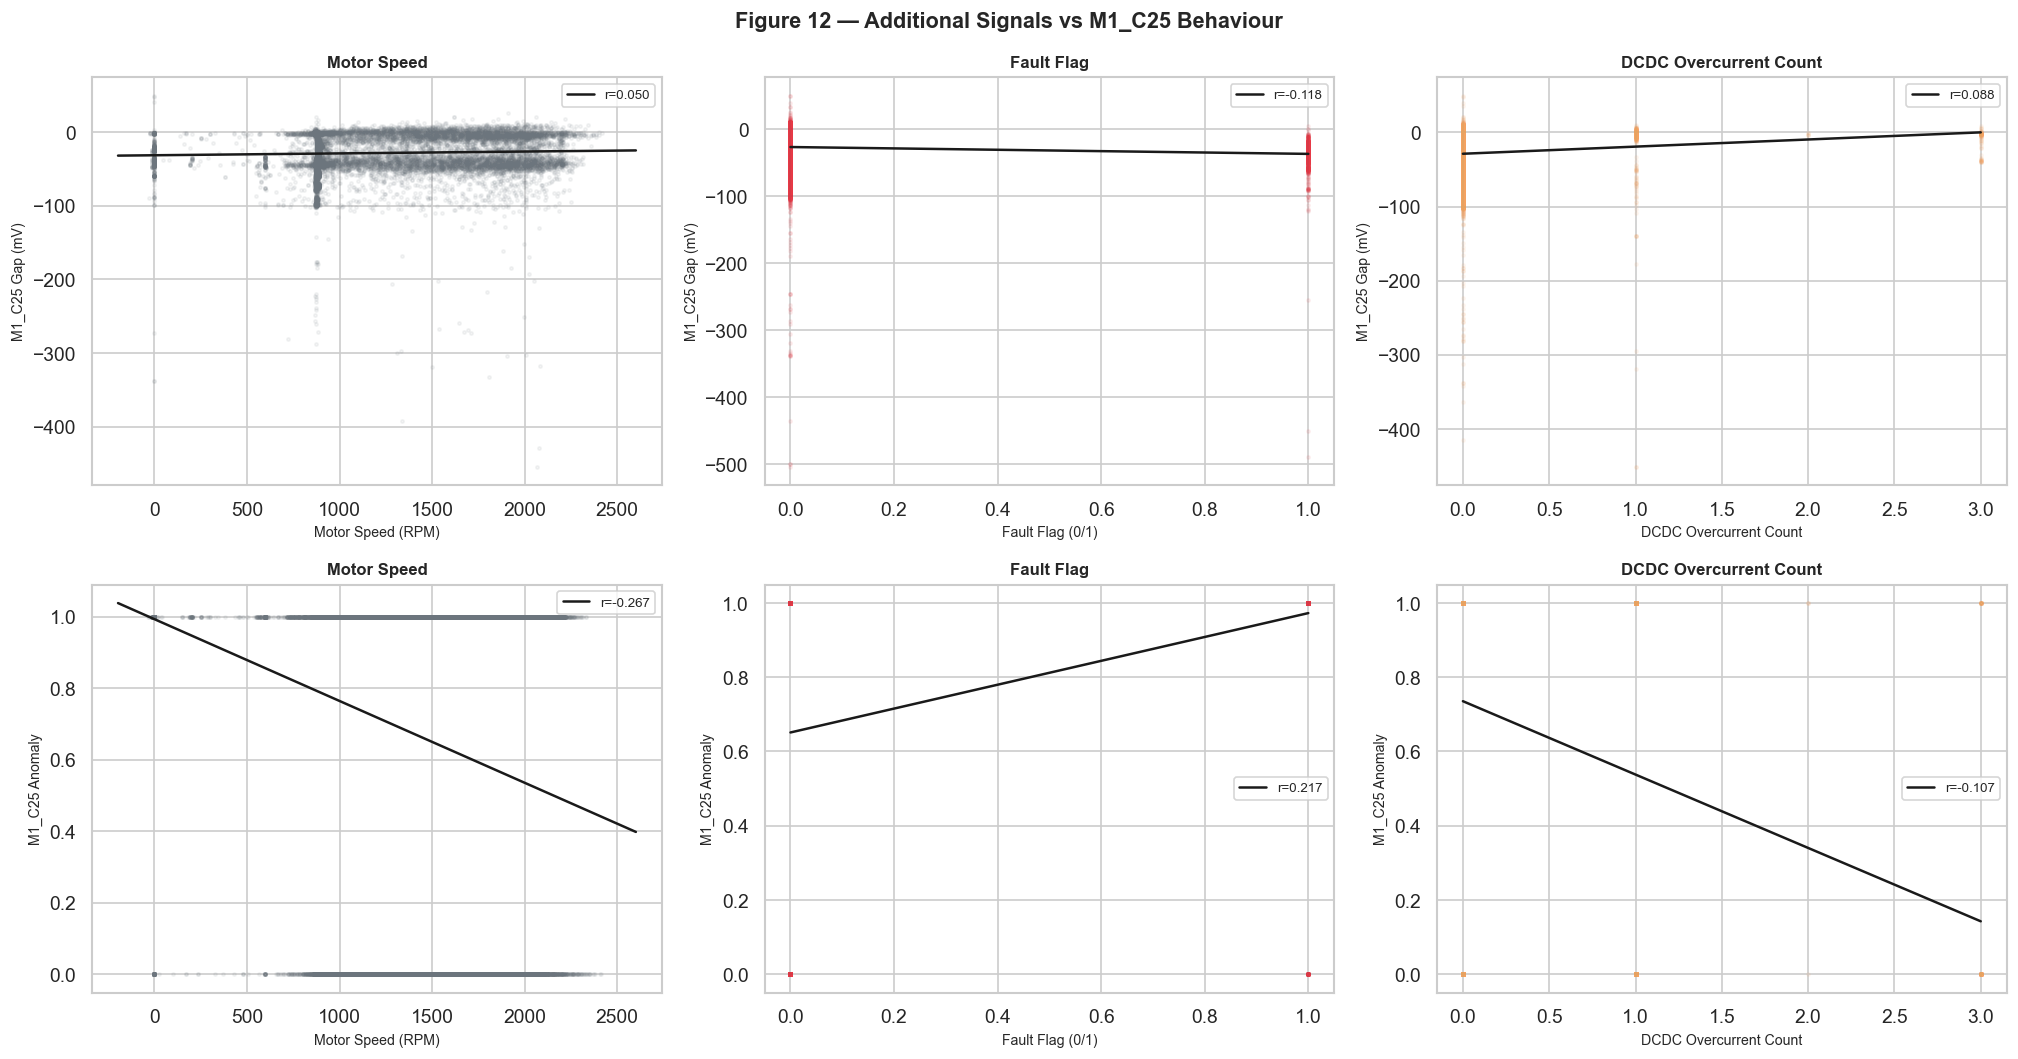

In [19]:
other_pairs = [
    ('motor_speed_rpm',        'M1_C25_delta',      'Motor Speed (RPM)',        'M1_C25 Gap (mV)',  GREY),
    ('fault_any',              'M1_C25_delta',      'Fault Flag (0/1)',          'M1_C25 Gap (mV)', RED),
    ('dcdc_overcurrent_count', 'M1_C25_delta',      'DCDC Overcurrent Count',   'M1_C25 Gap (mV)', ORANGE),
    ('motor_speed_rpm',        'M1_C25_is_outlier', 'Motor Speed (RPM)',         'M1_C25 Anomaly',  GREY),
    ('fault_any',              'M1_C25_is_outlier', 'Fault Flag (0/1)',          'M1_C25 Anomaly',  RED),
    ('dcdc_overcurrent_count', 'M1_C25_is_outlier', 'DCDC Overcurrent Count',   'M1_C25 Anomaly',  ORANGE),
]

print('=== Other Signal Correlations ===')
r_other = {}
for x_col, y_col, x_lab, y_lab, _ in other_pairs:
    sub = df_exp[[x_col, y_col]].dropna()
    if len(sub) < 10 or sub[x_col].nunique() < 2:
        print(f'  {x_lab:35s} → {y_lab:20s}  SKIP (constant or insufficient data)')
        continue
    r, p = stats.pearsonr(sub[x_col], sub[y_col])
    sig = '***' if p < 0.001 else ('*' if p < 0.05 else 'ns')
    strength = 'Strong' if abs(r)>0.5 else 'Moderate' if abs(r)>0.3 else 'Weak' if abs(r)>0.1 else 'Negligible'
    r_other[f'{x_col}_{y_col}'] = round(r, 4)
    print(f'  {x_lab:35s} → {y_lab:20s}  r={r:.4f}  {strength} ({sig})')

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, (x_col, y_col, x_lab, y_lab, clr) in zip(axes.flat, other_pairs):
    sub = df_exp[[x_col, y_col]].dropna()
    if len(sub) < 10 or sub[x_col].nunique() < 2:
        ax.text(0.5, 0.5, 'Insufficient / constant data', ha='center', va='center',
                transform=ax.transAxes, color='grey')
        ax.set_title(x_lab.split('(')[0].strip(), fontweight='bold', fontsize=10)
        continue
    smp4 = sub.sample(min(20_000, len(sub)), random_state=6)
    ax.scatter(smp4[x_col], smp4[y_col], alpha=0.07, s=4, color=clr, rasterized=True)
    sl2, ic2, r2, *_ = stats.linregress(sub[x_col], sub[y_col])
    xr2 = np.linspace(sub[x_col].min(), sub[x_col].max(), 200)
    ax.plot(xr2, sl2*xr2+ic2, 'k-', lw=1.5, label=f'r={r2:.3f}')
    ax.set_xlabel(x_lab, fontsize=8.5); ax.set_ylabel(y_lab, fontsize=8.5)
    ax.set_title(x_lab.split('(')[0].strip(), fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Figure 12 — Additional Signals vs M1_C25 Behaviour', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 6.5 Full Expanded Correlation Matrix — All Signals

Rows for full correlation matrix: 1,492,480


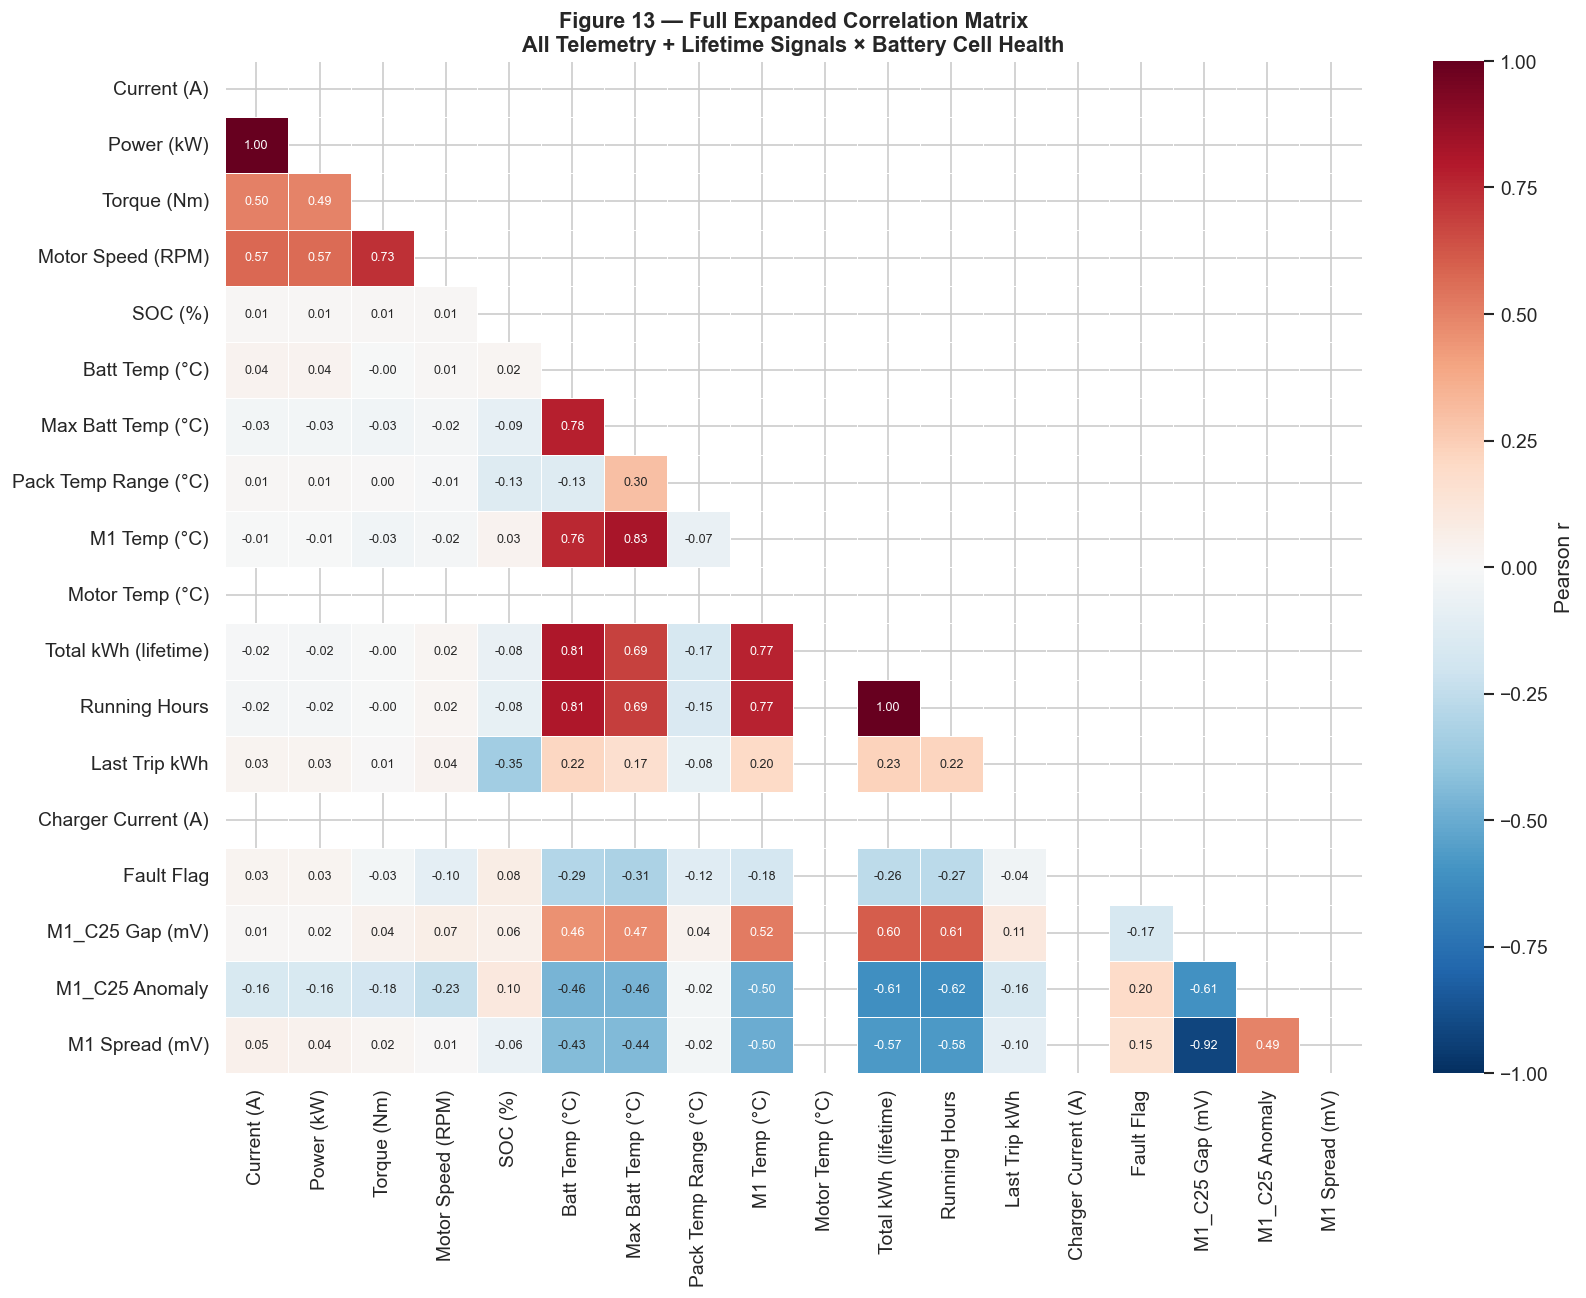


=== Signals ranked by correlation with M1_C25 Gap ===
  M1 Spread (mV)                 r=-0.9206  STRONG
  Running Hours                  r=+0.6071  STRONG
  M1_C25 Anomaly                 r=-0.6063  STRONG
  Total kWh (lifetime)           r=+0.6024  STRONG
  M1 Temp (°C)                   r=+0.5214  STRONG
  Max Batt Temp (°C)             r=+0.4695  MODERATE
  Batt Temp (°C)                 r=+0.4561  MODERATE
  Fault Flag                     r=-0.1665  Weak
  Last Trip kWh                  r=+0.1052  Weak
  Motor Speed (RPM)              r=+0.0655  Negligible
  SOC (%)                        r=+0.0622  Negligible
  Pack Temp Range (°C)           r=+0.0416  Negligible
  Torque (Nm)                    r=+0.0413  Negligible
  Power (kW)                     r=+0.0154  Negligible
  Current (A)                    r=+0.0133  Negligible
  Motor Temp (°C)                r=+nan  Negligible
  Charger Current (A)            r=+nan  Negligible


In [20]:
all_corr_cols = {
    'abs_current_a':           'Current (A)',
    'output_power_kw':         'Power (kW)',
    'motor_torque_value_nm':   'Torque (Nm)',
    'motor_speed_rpm':         'Motor Speed (RPM)',
    'soc_pct':                 'SOC (%)',
    'avg_battery_temp_c':      'Batt Temp (°C)',
    'max_battery_temp_c':      'Max Batt Temp (°C)',
    'pack_temp_range':         'Pack Temp Range (°C)',
    'module_1_temp_mean':      'M1 Temp (°C)',
    'motor_temperature_c':     'Motor Temp (°C)',
    'total_kwh_consumed':      'Total kWh (lifetime)',
    'running_hours':           'Running Hours',
    'last_trip_kwh':           'Last Trip kWh',
    'charger_current_demand_a':'Charger Current (A)',
    'fault_any':               'Fault Flag',
    'M1_C25_delta':            'M1_C25 Gap (mV)',
    'M1_C25_is_outlier':       'M1_C25 Anomaly',
    'm1_vrange_mv':            'M1 Spread (mV)',
}
corr_all = df_exp[list(all_corr_cols.keys())].rename(columns=all_corr_cols).dropna()
print(f'Rows for full correlation matrix: {len(corr_all):,}')
cm = corr_all.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(cm, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            annot_kws={'size': 7.5}, cbar_kws={'label':'Pearson r'})
ax.set_title('Figure 13 — Full Expanded Correlation Matrix\nAll Telemetry + Lifetime Signals × Battery Cell Health',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Print M1_C25 row sorted by absolute correlation
c25_row = cm['M1_C25 Gap (mV)'].drop('M1_C25 Gap (mV)').sort_values(key=abs, ascending=False)
print('\n=== Signals ranked by correlation with M1_C25 Gap ===')
for sig, r in c25_row.items():
    strength = 'STRONG' if abs(r)>0.5 else 'MODERATE' if abs(r)>0.3 else 'Weak' if abs(r)>0.1 else 'Negligible'
    print(f'  {sig:30s} r={r:+.4f}  {strength}')